# Deep Learning with PyTorch Step-by-Step: A Beginner's Guide

# Chapter 6

In [1]:
'''from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))'''

'from IPython.core.display import display, HTML\ndisplay(HTML("<style>.container { width:80% !important; }</style>"))'

In [2]:
'''try:
    import google.colab
    import requests
    url = 'https://raw.githubusercontent.com/dvgodoy/PyTorchStepByStep/master/config.py'
    r = requests.get(url, allow_redirects=True)
    open('config.py', 'wb').write(r.content)    
except ModuleNotFoundError:
    pass'''

from config import *
config_chapter6()
# This is needed to render the plots in this chapter
from plots.chapter6 import *

ModuleNotFoundError: No module named 'config'

In [2]:
import numpy as np
from PIL import Image
from copy import deepcopy

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision.transforms.v2 import Compose, ToImage, Normalize, \
ToPILImage, Resize, ToDtype
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, \
MultiStepLR, CyclicLR, LambdaLR

from stepbystep.v2 import StepByStep
from data_generation.rps import download_rps

# Rock, Paper, Scissors

## Rock Paper Scissors Dataset

>This dataset was created by Laurence Moroney (lmoroney@gmail.com / [laurencemoroney.com](http://www.laurencemoroney.com)) and can be found in his site: [Rock Paper Scissors Dataset](https://laurencemoroney.com/datasets.html#rock-paper-scissors-dataset). 

>The dataset is licensed as Creative Commons (CC BY 2.0). No changes were made to the dataset.

In [3]:
# This may take a couple of minutes...
download_rps()

이 데이터셋은 Laurence Moroney
(lmoroney@gmail.com / laurencemoroney.com)에 의해 제작되었으며,
그의 사이트인 “Rock Paper Scissors Dataset”에서 확인할 수 있다.

이 데이터셋은 Creative Commons 라이선스(CC BY 2.0)를 따른다.
데이터셋 자체에는 어떠한 수정도 가해지지 않았다.

이 데이터셋은 총 2,892장의 이미지를 포함하고 있으며,
흰색 배경 위에서 다양한 손 모양으로 가위(scissors), 바위(rock), 보(paper) 자세를 취한 이미지들로 구성되어 있다.
또한 이 데이터셋은 CGI(Computer Generated Imagery) 기술을 사용하여 생성된 합성(synthetic) 데이터셋이다.

각 이미지는:

크기: 300×300 픽셀
채널 수: 4개(RGBA)

로 구성되어 있다.

RGBA는:

Red
Green
Blue
Alpha

를 의미한다.
이는 일반적인 RGB 색상 모델에 투명도(opacity)를 나타내는 Alpha 채널이 추가된 형태이다.
하지만 Alpha 채널은 이후 과정에서 제거될 예정이므로 크게 신경 쓰지 않아도 된다.

훈련 데이터셋(training set)은 총 2,520장의 이미지로 구성되어 있으며,
테스트 데이터셋(test set)은 총 372장의 이미지로 구성되어 있다.

노트북에서는 데이터셋을 자동으로 다운로드 및 압축 해제하여:

rps
rps-test-set

폴더에 저장한다.

아래에는 각 손동작(바위, 가위, 보)에 대한 예시 이미지가 제시되어 있다.

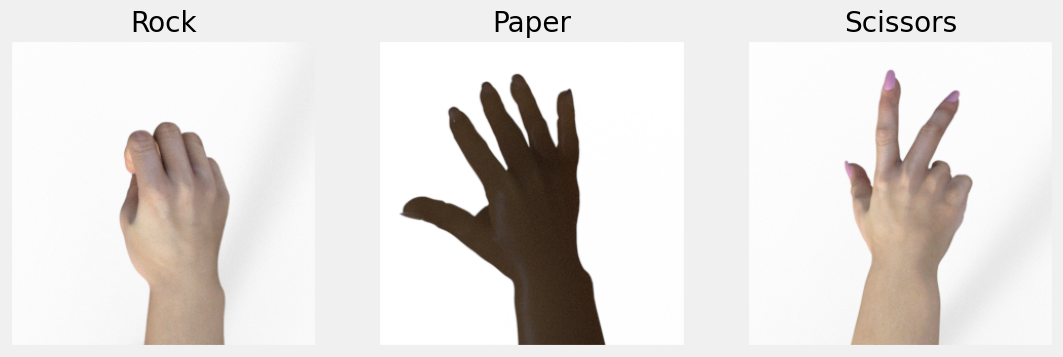

In [4]:
fig = figure1()

# Data Preparation

## ImageFolder

이번에는 데이터 전처리 단계가 조금 더 복잡해진다.
이번에는 이미지를 실제로 표준화(standardization)할 것이기 때문이다.
즉, 이전처럼 단순한 min-max scaling만 사용하는 것이 아니다.

또한 이번에는 `ImageFolder` 데이터셋 클래스를 사용할 수 있다.

`ImageFolder`는 특정한 데이터셋 자체가 아니라,
사용자가 가진 이미지 데이터를 쉽게 불러오기 위한 범용(generic) 데이터셋 클래스이다.

단, 다음과 같은 폴더 구조를 따라야 한다:

* 각 클래스(class)마다 하나의 하위 폴더(sub-folder)를 만든다.
* 폴더 이름은 클래스 이름으로 지정한다.
* 해당 폴더 안에는 그 클래스에 속하는 이미지들을 넣는다.

Rock Paper Scissors 데이터셋은 바로 이러한 구조로 정리되어 있다.

즉, 훈련 데이터셋의 `rps` 폴더 내부에는 다음과 같은 세 개의 하위 폴더가 존재한다:

* `rock`
* `paper`
* `scissors`

각 폴더 안에는 해당 손동작에 해당하는 이미지들이 저장되어 있다.


이 데이터셋은 완전히 균형 잡힌(balanced) 데이터셋이기도 하다.
각 하위 폴더(sub-folder)는 자신에 해당하는 클래스의 이미지 840장을 포함하고 있다.

`ImageFolder` 데이터셋은 기본적으로 루트 폴더(root folder)만 필요로 한다.
우리의 경우에는 `rps` 폴더가 루트 폴더이다.

하지만 추가적으로 네 개의 선택적(optional) 인자를 받을 수 있다.

* `transform`:
  이미 익숙한 인자이다.
  각 이미지에 어떤 변환(transformations)을 적용할지를 지정한다.
  예를 들어, 이전 장에서 사용했던 데이터 증강(data augmentation) 변환들이 여기에 해당한다.

* `target_transform`:
  지금까지 우리의 target(label)은 항상 정수(integer)였기 때문에 크게 의미가 없었다.
  하지만 target 자체가 이미지인 경우에는 의미가 생긴다.
  예를 들어, segmentation(이미지 분할) 문제에서는 입력 이미지뿐 아니라 정답 이미지에도 변환을 적용해야 한다.

* `loader`:
  주어진 경로(path)로부터 이미지를 불러오는 함수이다.
  PIL(Python Imaging Library)로 처리할 수 없는 특이하거나 비표준적인 이미지 형식을 사용하는 경우 활용할 수 있다.

* `is_valid_file`:
  파일이 손상(corrupted)되었는지 여부를 검사하는 함수이다.

이제 실제로 데이터셋을 생성해보자.


In [7]:
temp_transform = Compose([Resize(28), ToImage(), ToDtype(torch.float32, scale=True)])
temp_dataset = ImageFolder(root='rps', transform=temp_transform)

여기서는 선택적(optional) 인자 중 `transform`만 사용하고 있으며,
변환(transformations)도 최소한으로만 적용하고 있다.

먼저 이미지를 28×28 픽셀 크기로 조정(resize)한다.
이 과정에서 PIL loader가 자동으로 이미지를 RGB 색상 모델로 변환하므로,
원래 존재하던 alpha 채널은 제거된다.

그 다음 이미지는 PyTorch tensor로 변환된다.

이미지 크기를 작게 만드는 이유는:

* 모델 학습 속도를 빠르게 하고
* CPU 환경에서도 보다 효율적으로 실행할 수 있도록 하기 위해서이다.

이제 데이터셋의 첫 번째 이미지를 가져와서,

* 이미지의 shape(형태)
* 해당 이미지의 label

을 확인해보자.


In [6]:
temp_dataset[0][0].shape, temp_dataset[0][1]

(torch.Size([3, 28, 28]), 0)

## Standardization

데이터를 표준화(standardization)하려면,
먼저 데이터의 평균(mean)과 표준편차(standard deviation)를 계산해야 한다.

그렇다면 우리의 Rock-Paper-Scissors 이미지 데이터의:

* 평균 픽셀 값(mean pixel value)
* 표준편차(standard deviation)

은 얼마일까?

이를 계산하려면 데이터를 실제로 불러와야 한다.

다행히도, 우리는 이미 크기가 28×28로 조정된 이미지들을 포함한 (임시) 데이터셋을 가지고 있다.

현재 부족한 것은 단 하나,
바로 데이터를 읽어올 `DataLoader`뿐이다.


In [8]:
temp_loader = DataLoader(temp_dataset, batch_size=16)

이 데이터 로더는 모델 학습(training)에 사용할 것이 아니므로,
데이터를 섞는(shuffling) 작업은 굳이 필요하지 않다.

우리가 이 데이터 로더를 사용하는 목적은 오직 통계값(statistics)을 계산하기 위해서이다.

그런데 `Normalize()` transform은 각 채널(channel)별 평균(mean)과 표준편차(std)을 필요로 한다.

따라서 우리는:

* 미니배치(images, labels)를 입력받아
* 각 이미지의 채널별 평균 픽셀값(mean)
* 채널별 표준편차(standard deviation)

를 계산하고,
모든 이미지에 대해 그 결과를 누적하는 함수를 만들어야 한다.

그리고 더 나아가,
이 함수를 `StepByStep` 클래스의 메서드(method)로 추가해보자.


In [ ]:
@staticmethod
def statistics_per_channel(images, labels):
    # NCHW
    n_samples, n_channels, n_height, n_weight = images.size()
    # Flatten HW into a single dimension
    # reshape을 하면 N , C, -1은 28*28이 된다. flatten의 역할을 한다.
    flatten_per_channel = images.reshape(n_samples, n_channels, -1)
    # x- x_i / 시그마 에서 x_i는 픽셀값, 시그마는 픽셀값의 표준편차
    # Computes statistics of each image per channel
    # Average pixel value per channel 
    # (n_samples, n_channels)
    means = flatten_per_channel.mean(axis=2)
    # Standard deviation of pixel values per channel
    # (n_samples, n_channels)
    stds = flatten_per_channel.std(axis=2)

    # Adds up statistics of all images in a mini-batch
    # (1, n_channels)
    # axis=0은 n_samples 방향으로 더한다는 뜻이다. 즉, 16개의 이미지의 평균과 표준편차를 더한다는 뜻이다.
    sum_means = means.sum(axis=0)
    sum_stds = stds.sum(axis=0)
    # Makes a tensor of shape (1, n_channels)
    # with the number of samples in the mini-batch
    n_samples = torch.tensor([n_samples]*n_channels).float()
    
    # Stack the three tensors on top of one another
    # (3, n_channels)
    return torch.stack([n_samples, sum_means, sum_stds], axis=0)

setattr(StepByStep, 'statistics_per_channel', statistics_per_channel)

In [10]:
first_images, first_labels = next(iter(temp_loader))
StepByStep.statistics_per_channel(first_images, first_labels)

tensor([[16.0000, 16.0000, 16.0000],
        [13.8748, 13.3048, 13.1962],
        [ 3.0507,  3.8268,  3.9754]])

이 함수를 첫 번째 미니배치(images)에 적용하면 위와 같은 결과를 얻을 수 있다.

각 열(column)은 하나의 채널(channel)을 나타내며,
각 행(row)은 순서대로 다음을 의미한다.

1. 데이터 개수(number of data points)
2. 평균값(mean values)의 합
3. 표준편차(standard deviations)의 합

이제 지난 장에서 만들었던 `loader_apply()` 메서드를 활용하면,
전체 데이터셋에 대한 합계(sum)를 손쉽게 계산할 수 있다.


In [11]:
results = StepByStep.loader_apply(temp_loader, StepByStep.statistics_per_channel)
results

tensor([[2520.0000, 2520.0000, 2520.0000],
        [2142.5356, 2070.0806, 2045.1444],
        [ 526.3025,  633.0677,  669.9556]])

따라서 우리는 각 채널(channel)에 대해:

* 평균(mean)의 평균값
* 표준편차(standard deviation)의 평균값

을 계산할 수 있다.

(“평균의 평균”이라는 표현이 조금 이상하게 들릴 수도 있지만 말이다.)

그리고 더 좋은 방법으로,
데이터 로더(data loader)를 입력받아
필요한 통계값(statistics)을 계산한 뒤
`Normalize()` transform 객체 자체를 반환하는 메서드로 만들어보자.


In [12]:
@staticmethod
def make_normalizer(loader):
    total_samples, total_means, total_stds = StepByStep.loader_apply(loader, StepByStep.statistics_per_channel)
    norm_mean = total_means / total_samples
    norm_std = total_stds / total_samples
    return Normalize(mean=norm_mean, std=norm_std)

setattr(StepByStep, 'make_normalizer', make_normalizer)

⚠️ 중요: 표준화(standardization)를 위한 통계값(mean, standard deviation)은
항상 훈련 데이터셋(training set)만 사용해서 계산해야 한다!

즉,
validation set이나 test set의 정보를 사용하면 안 된다.

그렇게 하면 validation/test 데이터의 정보가 모델 학습 과정에 새어 들어가는(data leakage) 문제가 발생하기 때문이다.

이제 이 메서드를 사용하여,
우리 데이터셋을 표준화(standardize)하는 transformation을 생성할 수 있다.

In [13]:
normalizer = StepByStep.make_normalizer(temp_loader)
normalizer

Normalize(mean=[tensor(0.8502), tensor(0.8215), tensor(0.8116)], std=[tensor(0.2089), tensor(0.2512), tensor(0.2659)], inplace=False)

PyTorch는 픽셀 값을 자동으로 `[0, 1]` 범위로 변환한다는 점을 기억하자.

예를 들어:

* 빨간색(red) 채널(첫 번째 채널)의 평균 픽셀값(mean)은 0.8502이고,
* 해당 채널의 평균 표준편차(standard deviation)는 0.2089이다.


### The Real Datasets

이번 장에서는 사전 학습된 모델(pre-trained model)을 사용할 때,
입력 데이터를 표준화하기 위해 미리 계산된 통계값(pre-computed statistics)을 사용할 것이다.

이제 임시 훈련 데이터셋에서 계산한 통계값을 이용하여,
`Normalize()` transform을 적용한 실제 데이터셋을 만들 차례이다.

데이터 준비 과정은 다음과 같다.


In [14]:
composer = Compose([Resize(28),
                    ToImage(),
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='rps', transform=composer)
val_data = ImageFolder(root='rps-test-set', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

비록 데이터셋의 두 번째 부분이 작성자에 의해 `rps-test-set`이라는 이름으로 제공되었지만,
우리는 이것을 validation dataset(검증 데이터셋)으로 사용할 것이다.

훈련 데이터셋(training set)과 검증 데이터셋(validation set)은
각각 서로 다른 폴더에 저장되어 있으므로,
추가로 데이터를 분할(split)할 필요는 없다.

다음으로, 두 데이터셋을 사용하여 각각에 대응하는 DataLoader를 생성한다.

이때 훈련 데이터셋(training set)은 반드시 shuffle(섞기)을 적용해야 한다는 점을 기억하자.

이제 실제 훈련 데이터셋(real training set)의 이미지 몇 개를 살펴보자.


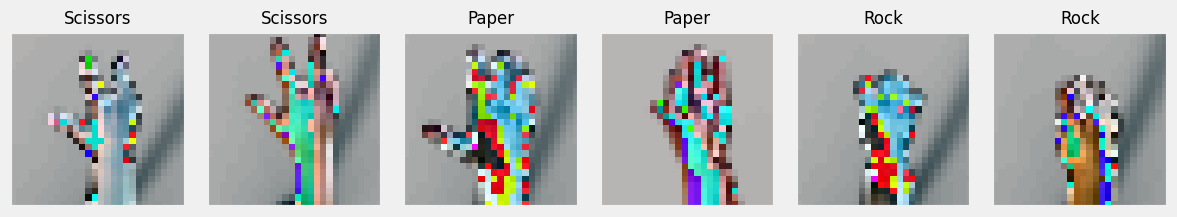

In [15]:
torch.manual_seed(88)
first_images, first_labels = next(iter(train_loader))

fig = figure2(first_images, first_labels)

“색깔이 왜 이상해졌죠?”

색깔이 잘못된 것은 아니다.
이것은 단지 픽셀 값(pixel values)을 표준화(standardization)했기 때문에 나타나는 효과일 뿐이다.

이제 우리는 컬러 이미지(colored images)를 다루게 되었으므로,
다시 convolution(합성곱)의 세계로 돌아가서
합성곱이 이러한 이미지를 어떻게 처리하는지 살펴보자.


## Convolutions Over Multiple Channels

이전에는:

* 단일 채널(single-channel) 이미지와
* 단일 채널(single-channel) 필터

를 사용했다.

또는 여러 개의 필터를 사용하더라도,
각 필터는 여전히 하나의 채널만 가지고 있었다.

하지만 이제는:

* 3채널 이미지(예: RGB)
* 3채널 필터

를 사용하게 된다.

여러 개의 필터를 사용하더라도,
각 필터는 여전히 이미지와 동일한 수의 채널(여기서는 3채널)을 가진다.

💡 즉,

> 모든 필터(filter)는 자신이 합성곱(convolution)하는 이미지와 동일한 수의 채널을 가진다.

3채널 필터를 3채널 이미지 위에서 합성곱 연산(convolution)하더라도,
최종적으로는 하나의 값(single value)이 생성된다.

이는 아래 그림에 나타난 것과 같다.


![](./images/3channel1.png)

이 과정을 다음과 같이 생각할 수 있다.

먼저,
이미지의 각 채널(channel)과 필터의 해당 채널 사이에서
원소별 곱(element-wise multiplication)을 수행하는 합성곱(convolution)을 각각 계산한다.

즉:

* Red 채널끼리 convolution
* Green 채널끼리 convolution
* Blue 채널끼리 convolution

을 수행하는 것이다.

그 결과,
각 채널마다 하나의 값이 생성되므로 총 세 개의 값이 나온다.

마지막으로,
이 세 채널의 결과값을 모두 더하면
우리가 기대하는 하나의 최종 값(single value)이 생성된다.

아래 그림이 이 과정을 더 잘 설명해줄 것이다.


![](./images/3channel2.png)

In [16]:
regions = np.array([[[[5, 0, 8],
                      [1, 9, 5],
                      [6, 0, 2]],
                     [[0, 5, 4],
                      [8, 1, 9],
                      [4, 8, 1]],
                     [[4, 2, 0],
                      [6, 3, 0],
                      [5, 2, 8]]]])
regions.shape

(1, 3, 3, 3)

In [17]:
three_channel_filter = np.array([[[[0, 3, 0],
                                   [1, 0, 1],
                                   [2, 1, 0]],
                                  [[2, 1, 0],
                                   [0, 3, 1],
                                   [1, -1, 0]],
                                  [[0, 1, 3],
                                   [-1, -2, 0],
                                   [2, 0, 1]]]])
three_channel_filter.shape

(1, 3, 3, 3)

In [18]:
result = F.conv2d(torch.as_tensor(regions), torch.as_tensor(three_channel_filter))
result, result.shape

(tensor([[[[39]]]]), torch.Size([1, 1, 1, 1]))

“필터가 두 개라면 어떻게 되나요?”

아래 그림은
각 필터(filter)가 합성곱(convolution)을 수행하는 이미지와 동일한 수의 채널(channel)을 가진다는 사실을 보여준다.


![](./images/3channel_filters1.png)

입력 이미지가 3개의 채널(channel)을 가지고 있고 필터(filter)가 2개라면,

각 필터 역시 3개의 채널을 가지게 되며,
최종 출력(output)은 2개의 채널을 가지게 된다.

즉,

> 합성곱(convolution)의 출력 채널 수는 사용한 필터(filter)의 개수와 같다.


## Fancier Model

이제는 `Sequential` 모델을 잠시 옆으로 두고,
다시 직접 모델 클래스를 만들어보자.

이번에는 생성자(constructor) 메서드가 두 개의 인자를 받도록 할 것이다.

* `n_filters`
* `p`

`n_filters`는 모델의 두 개의 convolution block 모두에서 사용할 출력 채널(output channels)의 개수로 사용된다.
(맞다, 이제 convolution block이 두 개가 된다!)

그리고 아래 코드에서 볼 수 있듯이,
`p`는 dropout의 확률(probability of dropout)로 사용된다.


In [19]:
class CNN2(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super(CNN2, self).__init__()
        self.n_feature = n_feature
        self.p = p
        # Creates the convolution layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_feature, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3)
        # Creates the linear layers
        # Where do this 5 * 5 come from?! Check it below
        self.fc1 = nn.Linear(n_feature * 5 * 5, 50) 
        self.fc2 = nn.Linear(50, 3)
        # Creates dropout layers
        self.drop = nn.Dropout(self.p)
        
    def featurizer(self, x):
        # Featurizer
        # First convolutional block
        # 3@28x28 -> n_feature@26x26 -> n_feature@13x13
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # Second convolutional block
        # n_feature * @13x13 -> n_feature@11x11 -> n_feature@5x5
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # Input dimension (n_feature@5x5)
        # Output dimension (n_feature * 5 * 5)
        x = nn.Flatten()(x)
        return x
    
    def classifier(self, x):
        # Classifier
        # Hidden Layer
        # Input dimension (n_feature * 5 * 5)
        # Output dimension (50)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)
        # Output Layer
        # Input dimension (50)
        # Output dimension (3)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)
        return x
                
    def forward(self, x):
        x = self.featurizer(x)
        x = self.classifier(x)
        return x

여기에는:

* 두 개의 convolutional layer
* 두 개의 linear layer

가 존재한다.

Linear layer는:

* `fc1` : hidden layer
* `fc2` : output layer

이다.

💡 주의:
“활성화 함수(activation function)와 max pooling 레이어는 어디에 있나요?”

max pooling layer는 학습해야 할 파라미터가 없기 때문에,
레이어 객체 대신 함수형(functional form)으로 사용할 수 있다.

즉:

* max pooling → `F.max_pool2d()`
* 활성화 함수(ReLU) → `F.relu()`

를 사용한다.

⚠️ 단, PReLU(Parametric ReLU)를 사용하는 경우에는
함수형(functional form)을 사용하면 안 된다.

왜냐하면 PReLU는:

* 음수 영역의 기울기(slope of negative part)
* 즉 leakage coefficient

를 학습해야 하기 때문이다.

이러한 방식의 장점은:

* 모델의 attribute(구성 요소)를 최소화할 수 있다는 점이다.

반면 단점도 있다.

레이어 객체가 존재하지 않기 때문에:

* hook을 걸 수 없고,
* activation function의 출력
* max pooling 결과

를 중간에서 캡처(capture)할 수 없게 된다.

========================

다음으로 두 개의 convolution block을
`featurizer`라는 이름의 메서드로 만들어보자.

입력 인자 `x`가 연속된(sequence) 모든 연산에서
입력이자 동시에 출력으로 사용되는 이러한 구조는 매우 흔하게 사용된다.

`featurizer`는 크기가:

```text
n_filters × 25
```

인 feature tensor를 생성한다.

다음 단계는 linear layer들을 사용하여 classifier를 구성하는 것이다.

여기서:

* 하나의 linear layer는 hidden layer(`fc1`)
* 다른 하나는 output layer(`fc2`)

역할을 한다.

그런데 여기에는 추가적인 요소가 있다.

각 linear layer 앞에는 dropout layer가 배치되어 있으며,
이 dropout layer는 생성자(constructor)의 두 번째 인자인 `p` 확률로 값을 제거(drop)한다.

=============================

“Dropout은 어떻게 동작하나요?”

이에 대해서는 다음 섹션에서 더 자세히 살펴볼 것이다.
하지만 먼저 모델 클래스를 완성해야 한다.

이제 남은 것은 무엇일까?

바로 `forward()` 메서드의 구현이다.

`forward()` 메서드는:

* 입력값(inputs)
  (여기서는 이미지들의 미니배치)
  를 받아서,

먼저 `featurizer`를 통과시킨다.

그 다음,
생성된 feature들을 classifier에 통과시킨다.

최종적으로 classifier는:

* 각 클래스(class)에 대해 하나씩,
* 총 세 개의 로짓(logits)

을 출력한다.



## Dropout

Dropout은 딥러닝 모델에서 매우 중요한 구성 요소이다.

Dropout은 regularizer(정규화 기법)로 사용되며,
모델이 과적합(overfitting)되는 것을 방지하려고 한다.

즉,
모델이 목표(target)를 달성하기 위해 단 하나의 방식에만 의존하지 못하도록 강제한다.

정규화(regularization)의 기본 아이디어는 다음과 같다.

모델을 그대로 두면,
모델은 목표를 달성하기 위한 “쉬운 길(easy way out)”을 찾으려고 한다.
(솔직히 모델 입장에서는 당연한 일이다!)

이것이 의미하는 바는,
훈련 데이터(training set)에서 특히 중요하게 보였던 몇몇 feature들에만 지나치게 의존할 수 있다는 것이다.

하지만:

* 그 feature들이 정말 중요한 것일 수도 있고,
* 단순한 통계적 우연(statistical fluke)일 수도 있다.

사실 아무도 확실히 알 수 없다.

모델을 더 강건하게(robust) 만들기 위해,
일부 feature들을 랜덤하게 사용할 수 없도록 차단한다.

그러면 모델은:

* 다른 방식으로
* 목표를 달성해야만 한다.

이 과정은 학습(training)을 더 어렵게 만들지만,
대신 더 좋은 일반화(generalization) 성능을 기대할 수 있다.

즉,
모델이 validation set처럼 처음 보는(unseen) 데이터에서도
더 잘 동작하게 된다.

이 개념은 random forest에서 사용하는 feature randomization과 매우 유사하다.

Random Forest에서는:

* 각 트리(tree)
* 또는 각 split

이 전체 feature가 아니라 일부 feature만 사용할 수 있다.

💡 “그렇다면 딥러닝 모델에서는 이런 ‘feature randomization’이 어떻게 동작하나요?”

이를 설명하기 위해,
우선 하나의 `nn.Dropout` 레이어만 포함된 간단한 sequential 모델을 만들어보자.


In [20]:
dropping_model = nn.Sequential(nn.Dropout(p=0.5))

“이걸 위해 왜 굳이 모델이 필요한가요?
함수형(functional form)인 `F.dropout()`을 사용하면 안 되나요?”

물론 가능하다.
여기서도 함수형 dropout인 `F.dropout()`을 사용해도 전혀 문제없다.

하지만 여기서는 또 다른 중요한 점도 함께 설명하고 싶었기 때문에,
잠시만 참고 따라와 주기 바란다.

그리고 dropout의 효과를 더 쉽게 이해할 수 있도록,
간격이 일정하게 배치된(points neatly spaced) 몇 개의 점들도 함께 만들어보자.


In [21]:
spaced_points = torch.linspace(.1, 1.1, 11)
spaced_points

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])

다음으로,
이 점들을 우리의 아주 단순한(amusingly simple) 모델의 입력값(input)으로 사용해보자.

In [22]:
torch.manual_seed(44)

dropping_model.train()
output_train = dropping_model(spaced_points)
output_train

tensor([0.0000, 0.4000, 0.0000, 0.8000, 0.0000, 1.2000, 1.4000, 1.6000, 1.8000,
        0.0000, 2.2000])

여기서 주목해야 할 점이 여러 가지 있다.

* 모델이 train mode 상태이다.
  (매우 중요하다! 이 점을 꼭 기억해두자.)

* 이 모델에는 학습할 weight가 전혀 없다.
  따라서 dropout은 weight를 제거하는 것이 아니라,
  입력값(inputs)을 제거(drop)한다는 사실이 분명해진다.

* 실제로는 단지 4개의 원소만 제거되었다!

* 그리고 남아 있는 원소들의 값이 이전과 달라졌다!

💡 “도대체 무슨 일이 일어나고 있는 걸까요?”

먼저,
dropout은 확률적으로(probabilistically) 동작한다.

즉,
각 입력값(input)은 50% 확률로 제거(drop)될 가능성이 있었다.

하지만 우리의 작은 예제에서는 우연히(chance),
10개 중 단지 4개만 실제로 제거된 것이다.
(이 점도 기억해두자!)


![](images/dropout_paper.png)

두 번째로,

남아 있는 원소들의 값은
`1/p` 비율만큼 비례적으로 조정되어야 한다.

우리의 예제에서는
그 비율이 2가 된다.

즉,
일부 입력값이 dropout으로 제거되었기 때문에,
남아 있는 값들의 크기를 증가시켜
전체적인 기대값(expected value)을 유지하는 것이다.


In [23]:
output_train / spaced_points

tensor([0., 2., 0., 2., 0., 2., 2., 2., 2., 0., 2.])

이러한 조정(adjustment)의 목적은,
dropout이 적용된 해당 레이어의 출력값(output) 전체 수준(level)을
유지하려는 데 있다.
(적어도 최대한 유지하려고 시도하는 것이다.)

이제 다음과 같은 상황을 가정해보자.

dropout 이후의 입력값(inputs)이
하나의 linear layer로 전달된다고 하자.

그리고 설명을 단순하게 하기 위해:

* 모든 weight는 1이고
* bias는 0이라고 가정하자.

이미 알고 있듯이,
linear layer는:

* weight와 입력값(inputs)을 곱한 뒤
* 그 결과를 모두 더한다(sum)

는 연산을 수행한다.


In [24]:
F.linear(output_train, weight=torch.ones(11), bias=torch.tensor(0))

tensor(9.4000)

합계(sum)는 9.4이다.

만약 조정 계수(adjusting factor)를 적용하지 않았다면,
이 값은 절반인 4.7이 되었을 것이다.

“그래서 뭐가 중요한 건가요?
왜 출력값의 수준(level)을 유지해야 하나요?”

그 이유는 evaluation mode에서는 dropout이 적용되지 않기 때문이다!

우리는 이전에도 잠깐 이야기했지만,
dropout은 본질적으로 랜덤(random)하게 동작한다.

따라서 동일한 입력(input)에 대해서도
매번 조금씩(혹은 꽤 많이) 다른 예측(prediction)을 만들 수 있다.

하지만 그런 동작은 원하지 않는다.
실제 서비스나 추론(inference) 상황에서는 매우 좋지 않기 때문이다.

그래서 모델을 `eval mode`로 전환해야 한다.
(그리고 이것이 내가 함수형 dropout 대신 모델 형태를 사용한 이유이기도 하다.)

이제 모델을 evaluation mode로 설정하고,
무슨 일이 일어나는지 살펴보자.

In [25]:
dropping_model.eval()
output_eval = dropping_model(spaced_points)
output_eval

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])

💡 드디어 train mode와 eval mode 사이의 실제 동작 차이가 등장했다!
너무 오래 기다린 셈이다!

입력값들은 단순히 그대로 통과(pass through)하고 있다.

그렇다면 이것이 의미하는 바는 무엇일까?

이 값들을 입력으로 받는 linear layer는 여전히:

* 입력값에 weight를 곱하고
* 그 결과를 모두 더하는(sum)

연산을 수행하게 된다.


In [26]:
F.linear(output_eval, weight=torch.ones(11), bias=torch.tensor(0))

tensor(6.6000)

이 값은 모든 입력값의 합(sum)이다.
(왜냐하면 모든 weight를 1로 설정했고, 어떤 입력값도 drop되지 않았기 때문이다.)

만약 조정 계수(adjusting factor)가 없었다면,
evaluation mode와 training mode의 출력값은 상당히 달라졌을 것이다.

그 이유는 evaluation mode에서는 더 많은 항들이 합산(add up)되기 때문이다.

💡 “그래도 아직 잘 납득이 안 되는데요…
조정을 하지 않았을 때의 출력 4.7이,
조정된 값 9.4보다 오히려 6.6에 더 가까운 것 아닌가요?”

이런 결과가 나온 이유는,
dropout이 확률적으로(probabilistically) 동작하기 때문이다.

실제로는 10개 중 단지 4개만 제거되었다.
(이것이 앞에서 기억해두라고 했던 부분이다.)

조정 계수(factor)는
실제로 제거된 개수가 아니라,
평균적으로 제거될 개수에 맞추어 계산된다.

우리는 dropout 확률을 50%로 설정했으므로,
평균적으로는 5개의 원소가 제거될 것으로 기대한다.

참고로,
random seed를 45로 바꾸고 코드를 다시 실행하면,
실제로 정확히 절반의 입력값이 제거된다.

그 경우 조정된 출력값은:

* 9.4가 아니라
* 6.4

가 된다.

이제 매번 random seed를 바꾸어 결과를 직접 확인하는 대신,
1,000개의 시나리오를 생성하여
dropout 이후 조정된 출력값들의 합(sum)이 어떤 분포(distribution)를 가지는지 계산해보자.


In [27]:
torch.manual_seed(17)
p = 0.5
distrib_outputs = torch.tensor([F.linear(F.dropout(spaced_points, p=p), 
                                         weight=torch.ones(11), bias=torch.tensor(0)) 
                                for _ in range(1000)])

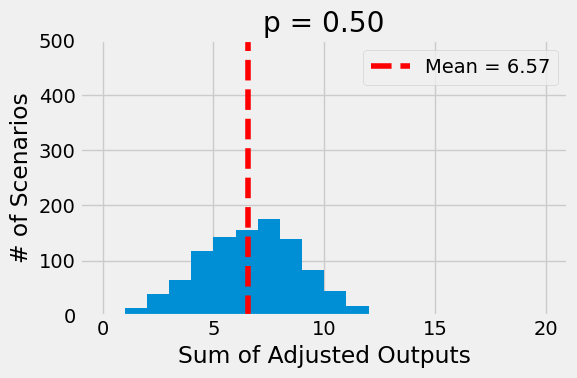

In [28]:
fig = figure7(p, distrib_outputs)

위 그림은,
주어진 입력값들에 대해 dropout이 적용된 단순한 linear layer의 출력이
더 이상 정확히 6.6이 되지 않는다는 것을 보여준다.

대신 출력값은:

* 0과 12 사이의 어떤 값이 될 수 있다.

하지만 모든 시나리오의 평균(mean)은
여전히 6.6에 매우 가깝다.

💡 Dropout은 단순히 일부 입력값을 제거(drop)하는 것만이 아니다.

dropout은 본질적으로 확률적(probabilistic)이기 때문에,
출력값(output) 자체를 하나의 분포(distribution)로 만들어낸다.

즉,

> 모델은 “dropout이 없었을 때의 출력값”을 중심(center)으로 하는
> 출력값들의 분포(distribution)를 처리하는 방법을 학습해야 한다.

또한,
dropout 확률(probability)의 선택은
출력값들이 얼마나 넓게 퍼질지(spread out)를 결정한다.


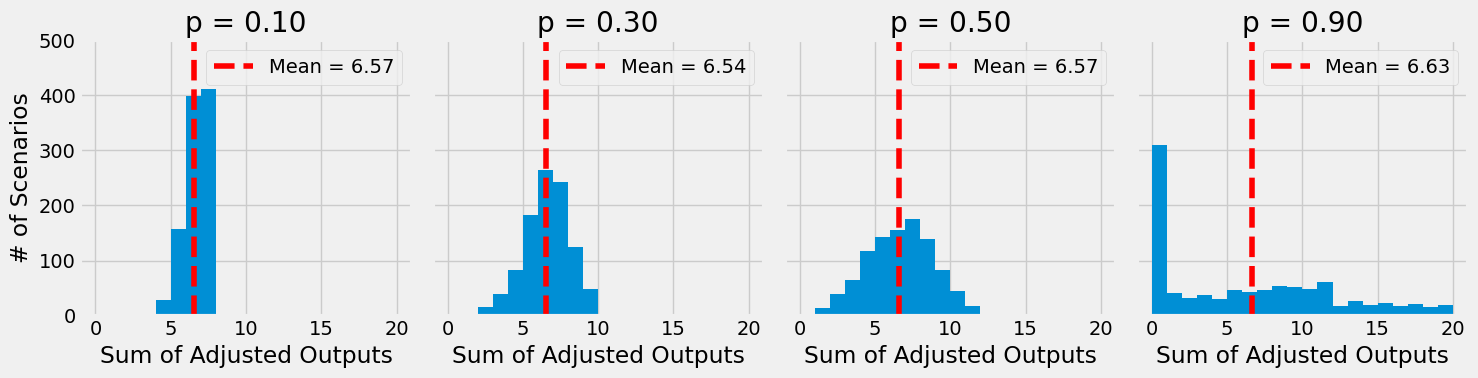

In [29]:
fig = figure8()

왼쪽 그림처럼 dropout이 거의 없는 경우(`p = 0.10`)에는,
조정된 출력값들의 합(sum of adjusted outputs)이
평균(mean) 주변에 매우 좁게 분포한다.

하지만 보다 일반적으로 사용하는 dropout 확률,
예를 들어:

* 30%
* 50%

정도에서는,
출력 분포(distribution)가 더 극단적인 값(extreme values)까지 나타날 수 있다.

만약 dropout 확률을 90%처럼 극단적으로 높이면,
출력 분포는 다소 “붕괴(degenerated)”된 형태가 된다.

즉,
출력값이 거의 완전히 무작위처럼 여기저기 흩어지게 된다.

또한 모든 입력값이 제거되는 경우도 많이 발생하기 때문에,
0 위치에 매우 높은 막대(bar)가 나타난다.

💡

> 출력값 분포의 분산(variance)은 dropout 확률이 커질수록 증가한다.

즉,
dropout 확률이 높을수록
모델은 학습하기 더 어려워진다.

그리고 바로 이것이 regularization(정규화)의 역할이다.

💡 “그렇다면 convolutional layer에도 dropout을 사용할 수 있나요?”


### Two-Dimensional Dropout

그렇다. 사용할 수 있다.
하지만 일반적인 dropout이 아니라,
convolutional layer 전용 dropout을 사용해야 한다.

바로 `nn.Dropout2d`이다.

하지만 이 dropout의 동작 방식은 조금 다르다.

일반 dropout은:

* 개별 입력값(individual inputs)
  (여기서는 특정 채널의 픽셀값)

을 제거(drop)한다.

반면 `Dropout2d`는:

* 전체 채널(channel)
* 또는 전체 필터(filter)

를 통째로 제거한다.

예를 들어,
어떤 convolutional layer가 10개의 filter를 생성했다고 하자.

이때:

* dropout probability = 50%

인 `Dropout2d`를 사용하면,
평균적으로 5개의 filter 전체가 제거된다.

그리고 제거되지 않은 나머지 filter들은
모든 픽셀값이 그대로 유지된다.

💡 “왜 픽셀 하나하나를 제거하지 않고,
채널 전체를 제거하나요?”

그 이유는,
인접한 픽셀(adjacent pixels)들은 서로 매우 강하게 상관관계(correlation)를 가지기 때문이다.

즉,
주변 픽셀들은 대체로 비슷한 값을 가진다.

따라서 이미지 안에 몇 개의 픽셀이 랜덤하게 사라지더라도,
주변 픽셀 값을 이용해 쉽게 보완(fill)할 수 있다.

예를 들어:

* 이미지에 dead pixel 몇 개가 존재해도
* 주변 픽셀만 보고 충분히 추정 가능하다.

즉,
픽셀 단위 dropout은 regularization 효과가 크지 않다.

반면,
RGB 이미지에서 채널 하나 전체가 제거된다면 상황이 완전히 달라진다.

예를 들어:

* Red 채널 전체 제거
* 또는 Blue 채널 전체 제거

같은 일이 발생하면,
이미지의 색 정보(color information)가 크게 변하게 된다.

이 경우에는:

* 누락된 채널 값을 추정하기가 훨씬 어렵다.
  (“사라진 채널 값을 맞혀보라”는 수준이 된다!)

아래 그림은:

* 일반 dropout
* 2차원 dropout(`Dropout2d`)

이 데이터셋 이미지에 각각 어떤 영향을 주는지를 보여준다.


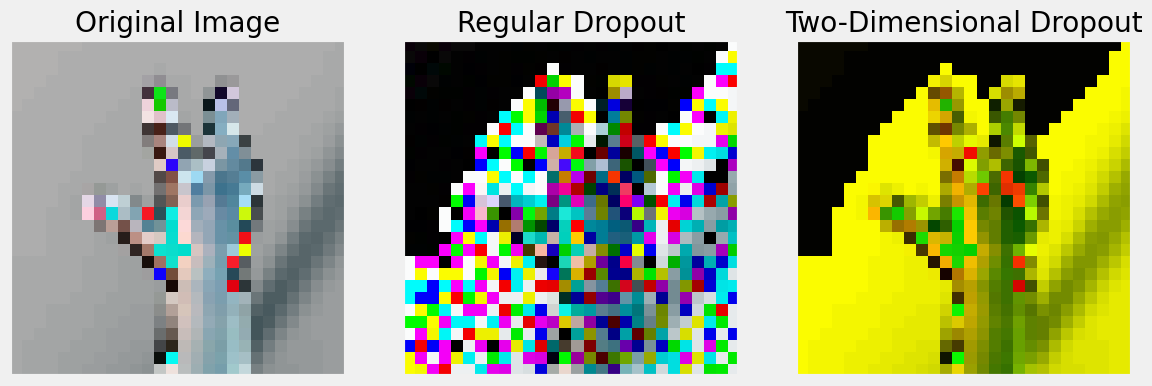

In [30]:
fig = figure9(first_images)

물론 더 깊은 층(deeper layers)으로 들어가면,
채널(channel)과 색상(color) 사이의 직접적인 대응 관계는 더 이상 존재하지 않는다.

하지만 각 채널은 여전히 어떤 feature(특징)를 인코딩하고 있다.

따라서 일부 채널들을 랜덤하게 제거(drop)함으로써,
2차원 dropout(`Dropout2d`)은 원하는 regularization 효과를 얻을 수 있다.

이제 dropout 확률을 30%로 설정하여,
모델이 학습하기 조금 더 어렵게 만들어보자.

그리고 그 상태에서 모델 성능이 어떻게 변하는지 살펴보자.


## Model Configuration

설정(configuration) 부분은 짧고 간단하다.
우리는 다음 세 가지를 만든다.

* 모델(model)
* 손실 함수(loss function)
* 옵티마이저(optimizer)

모델은 우리가 만든 `CNN2` 클래스의 인스턴스로 만들 것이다.
이 모델은:

* filter 개수: 5개
* dropout 확률: 30%

로 설정된다.

우리 데이터셋에는 세 개의 클래스가 있으므로,
손실 함수로 `nn.CrossEntropyLoss()`를 사용한다.

이 손실 함수는 모델이 출력하는 세 개의 로짓(logits)을 입력으로 받아 손실을 계산한다.

---

## Optimizer

옵티마이저와 관련해서는,
이번에는 SGD optimizer를 버리고 Adam을 사용해보자.

Stochastic Gradient Descent(SGD)는 Chapter 0에서 배웠듯이
단순하고 직관적인 방법이다.

하지만 속도가 느리다는 단점이 있다.

지금까지는 문제들이 비교적 단순했기 때문에
SGD의 학습 속도가 큰 문제가 되지 않았다.

하지만 모델이 조금 더 복잡해지면,
다른 optimizer를 선택하는 것이 도움이 될 수 있다.

Adaptive Moment Estimation, 즉 Adam은
adaptive learning rate를 사용한다.

즉, 각 parameter마다 learning rate를 따로 계산한다.

맞다. 제대로 읽은 것이다.

> 각 parameter가 자기만의 learning rate를 갖는다!

Adam optimizer의 `state_dict()`를 자세히 살펴보면,
모델의 각 layer parameter와 같은 형태(shape)를 가진 tensor들을 찾을 수 있다.

Adam은 이 tensor들을 사용하여
각 parameter에 대응하는 learning rate를 계산한다.

정말 그렇다!

Adam은 빠르게 좋은 결과를 얻는 것으로 알려져 있으며,
대체로 안전한 optimizer 선택지라고 볼 수 있다.

Adam의 내부 동작 방식에 대해서는
이후 섹션에서 다시 살펴볼 것이다.

---

## Learning Rate

또 하나 기억해야 할 점은,
이제 learning rate로 `0.1`은 더 이상 적절하지 않다는 것이다.

learning rate가 너무 높으면 어떤 일이 발생하는지 기억하는가?

* loss가 내려가지 않거나
* 더 나쁘게는 loss가 올라간다.

따라서 훨씬 더 작은 learning rate를 사용해야 한다.

이 예제에서는 `3e-4`를 사용해보자.

이는 일명 “Karpathy’s Constant”[100]라고 불리는 값이다.

비록 농담처럼 붙은 이름이지만,
여전히 적절한 크기의 범위(order of magnitude)에 해당하므로,
한번 사용해볼 만하다.


In [31]:
torch.manual_seed(13)
model_cnn2 = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2 = optim.Adam(model_cnn2.parameters(), lr=3e-4)

## Model Training

In [8]:
sbs_cnn2 = StepByStep(model_cnn2, multi_loss_fn, optimizer_cnn2)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(10)

NameError: name 'model_cnn2' is not defined

이 모델은 이전 모델들보다 훨씬 더 복잡하기 때문에,
학습(training)에 어느 정도 시간이 걸릴 것이라고 예상해야 한다.

예를 들어,
이번 모델은:

* 파라미터 수가 6,823개

인 반면,

지난 장의 모델은:

* 단지 213개의 파라미터

만 가지고 있었다.

학습이 완료되면,
계산된 loss 값들은 아래와 같은 형태를 보이게 된다.


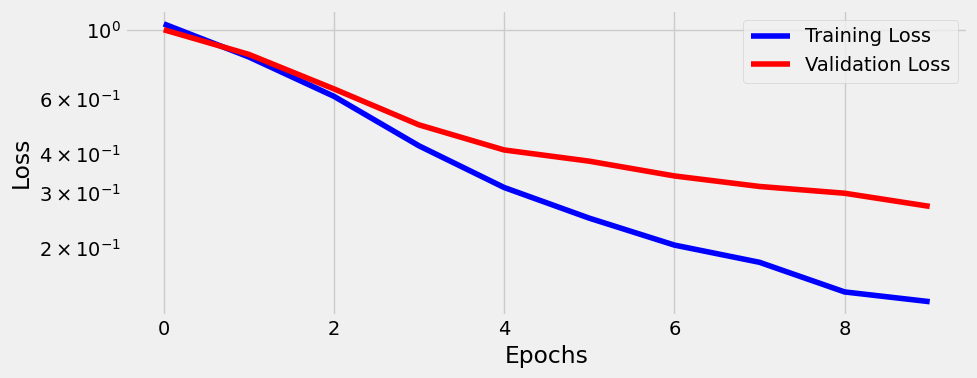

In [33]:
fig = sbs_cnn2.plot_losses()

### Accuracy

In [34]:
StepByStep.loader_apply(val_loader, sbs_cnn2.correct)

tensor([[ 89, 124],
        [118, 124],
        [117, 124]])

모델은 전체 372개 중 313개를 올바르게 분류했다.

즉,
validation set에서의 정확도(accuracy)는:

```text id="h2kpvz"
84.1%
```

이다.

꽤 괜찮은 성능이라고 볼 수 있다!


### Regularizing Effect

Dropout layer는 regularization, 즉 정규화를 위해 사용된다.

다시 말해,
dropout은 과적합(overfitting)을 줄이고
일반화 성능(generalization)을 향상시켜야 한다.

적어도 그렇게들 말한다. :-)

이제 이 주장을 경험적으로(empirically) 확인해보자.

이를 위해 원래 모델과 모든 조건은 동일하지만,
dropout만 제거한 모델을 학습시킨다.

그런 다음,
이 모델의 loss와 accuracy를
dropout을 사용한 기존 모델과 비교해보자.


In [35]:
torch.manual_seed(13)
# Model Configuration
model_cnn2_nodrop = CNN2(n_feature=5, p=0.0)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2_nodrop = optim.Adam(model_cnn2_nodrop.parameters(), lr=3e-4)
# Model Training
sbs_cnn2_nodrop = StepByStep(model_cnn2_nodrop, multi_loss_fn, optimizer_cnn2_nodrop)
sbs_cnn2_nodrop.set_loaders(train_loader, val_loader)
sbs_cnn2_nodrop.train(10)

그 다음,
위 모델, 즉 dropout을 사용하지 않은 모델의 loss를
이전 모델, 즉 30% dropout을 사용한 모델의 loss와 함께 그래프로 나타낼 수 있다.


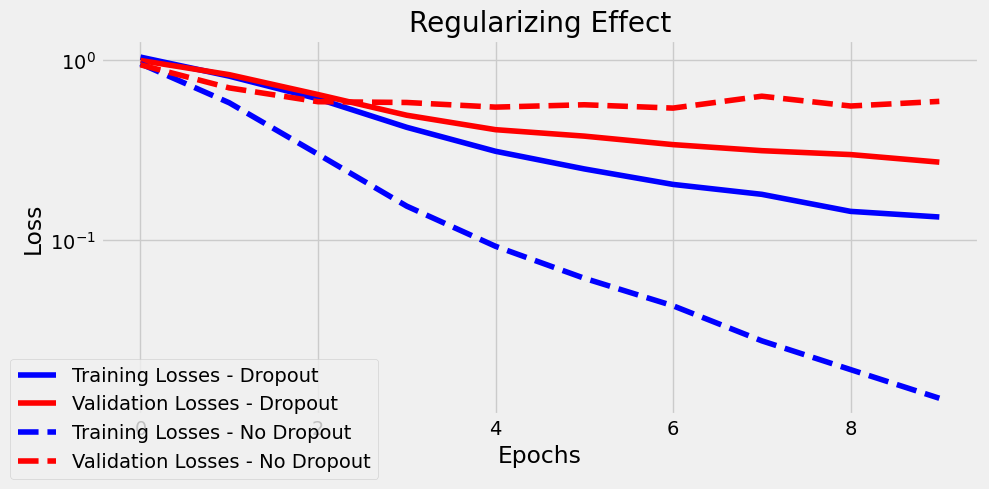

In [36]:
fig = figure11(sbs_cnn2.losses, sbs_cnn2.val_losses, sbs_cnn2_nodrop.losses, sbs_cnn2_nodrop.val_losses)

이 그림은 dropout이 가지는 regularization 효과를 매우 잘 보여준다.

* Dropout을 사용할 경우 training loss는 더 높다.
  결국 dropout은 학습(training)을 더 어렵게 만들기 때문이다.

* 반면 dropout을 사용할 경우 validation loss는 더 낮다.
  이는 모델이 더 잘 일반화(generalize)되고 있으며,
  처음 보는 데이터(unseen data)에 대해 더 좋은 성능을 내고 있다는 의미이다.

그리고 바로 이것이 dropout과 같은 regularization 기법을 사용하는 핵심 목적이다.

우리는 이러한 효과를
두 모델과 두 데이터셋의 accuracy를 비교함으로써도 확인할 수 있다.

먼저,
training 데이터에 과적합(overfit)될 것으로 예상되는
dropout 없는(no dropout) 모델부터 살펴보자.


In [37]:
print(
    StepByStep.loader_apply(train_loader, sbs_cnn2_nodrop.correct).sum(axis=0), 
    StepByStep.loader_apply(val_loader, sbs_cnn2_nodrop.correct).sum(axis=0)
)

tensor([2520, 2520]) tensor([293, 372])


훈련 데이터셋(training set)에서는 무려:

```text id="7j4s1j"
99.92%
```

의 정확도(accuracy)를 보였다!

반면 validation set에서는:

```text id="lw7m6v"
78.76%
```

의 정확도만 기록했다.

이건 상당히 과적합(overfitting)된 것처럼 보인다!

이제 regularization이 적용된,
즉 dropout을 사용한 버전의 모델을 살펴보자.


In [38]:
print(
    StepByStep.loader_apply(train_loader, sbs_cnn2.correct).sum(axis=0),
    StepByStep.loader_apply(val_loader, sbs_cnn2.correct).sum(axis=0)
)

tensor([2503, 2520]) tensor([324, 372])


훈련 데이터셋(training set)에서는:

```text id="4kxtoq"
99.36%
```

의 정확도를 기록했다.
여전히 상당히 높은 수치이다!

하지만 이제 validation set에서는:

```text id="1yk7ev"
84.13%
```

의 정확도를 얻었다.

즉,
training accuracy와 validation accuracy 사이의 차이(gap)가 더 줄어들었다.

이러한 현상은 일반적으로 매우 좋은 신호이다.

왜냐하면 모델이:

* training 데이터만 외우는 것이 아니라,
* 새로운 데이터에도 더 잘 일반화(generalize)

하고 있다는 뜻이기 때문이다.

또한 dropout 확률(probability)을 다양하게 바꾸어보면서,
결과가 얼마나 더 좋아지는지
혹은 오히려 더 나빠지는지도 직접 관찰해볼 수 있다.


### Visualizing Filters

이 모델에는 두 개의 convolutional layer가 있으므로,
이제 이들을 시각화해보자.

먼저 첫 번째 convolutional layer인 `conv1`을 살펴보면,
다음과 같은 결과를 얻을 수 있다.


In [39]:
model_cnn2.conv1.weight.shape

torch.Size([5, 3, 3, 3])

그 shape를 보면,
`conv1`이 세 개의 입력 채널 각각에 대해
5개의 filter를 생성했다는 것을 알 수 있다.

즉 전체적으로는:

```text
5 × 3 = 15개 filter
```

가 있는 셈이다.

그리고 각 filter의 크기는:

```text
3 × 3 pixels
```

이다.


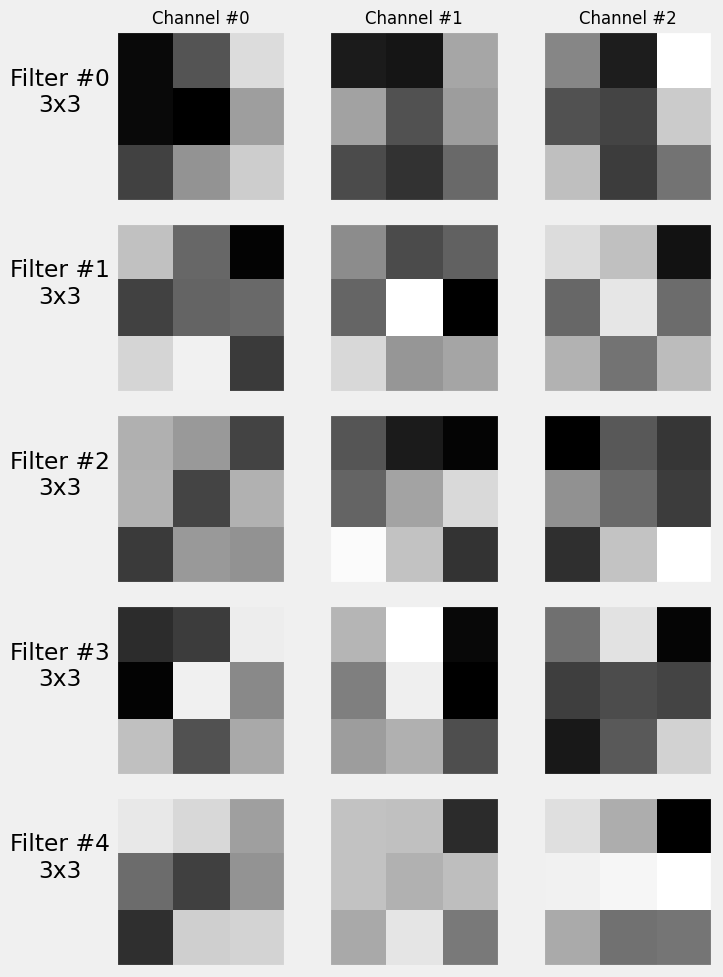

In [40]:
fig = sbs_cnn2.visualize_filters('conv1')

In [41]:
model_cnn2.conv2.weight.shape

torch.Size([5, 5, 3, 3])

두 번째 convolutional layer인 `conv2`를 살펴보면,
다음과 같은 결과를 얻을 수 있다.


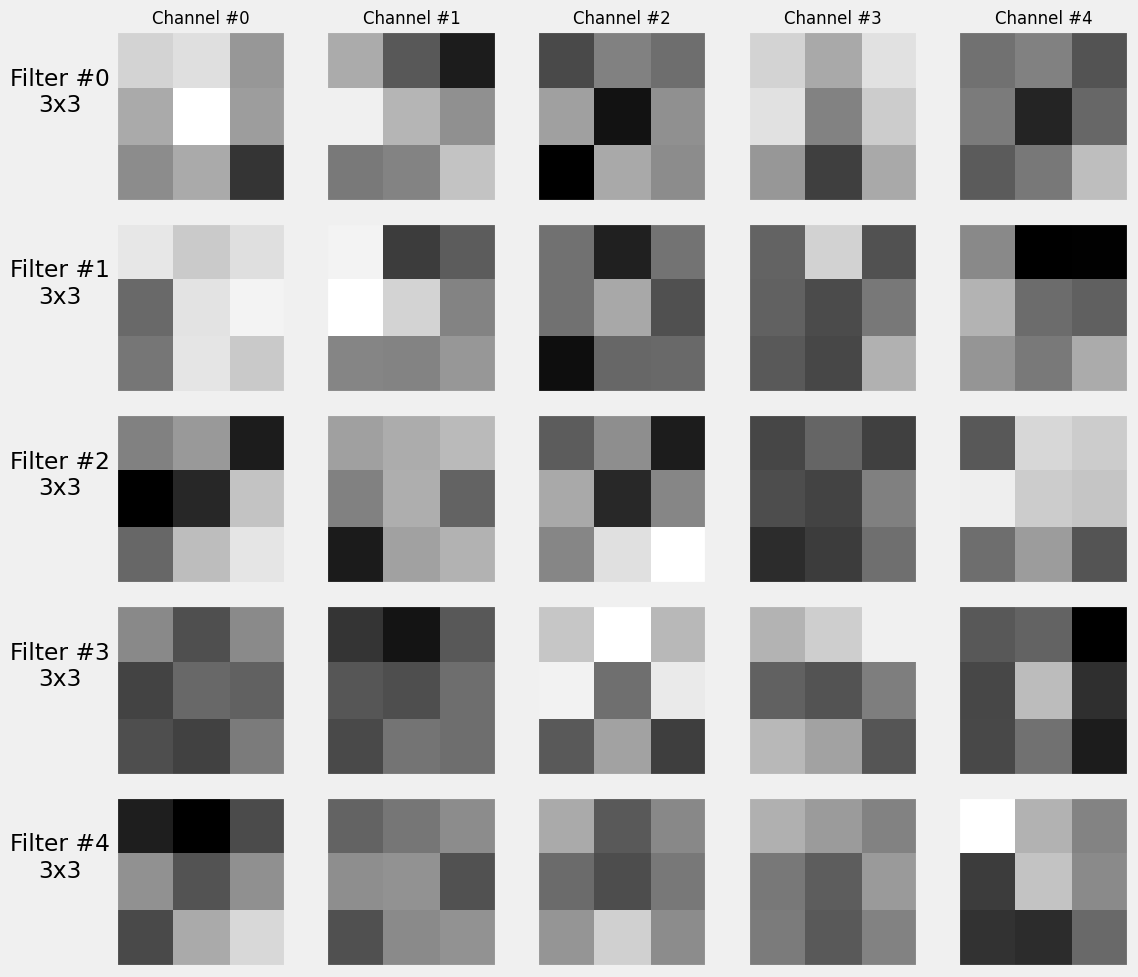

In [42]:
fig = sbs_cnn2.visualize_filters('conv2')

그 shape를 보면,
`conv2`는 다섯 개의 입력 채널 각각에 대해
5개의 filter를 생성했다는 것을 알 수 있다.

즉 전체적으로는:

```text
5 × 5 = 25개 filter
```

가 존재한다.

그리고 각 filter의 크기는:

```text
3 × 3 pixels
```

이다.


## Learning Rates

### Finding LR

알고 보니 learning rate를 그렇게 grid search 방식으로 일일이 찾을 필요는 없다.

2017년에 Leslie N. Smith는
Cyclical Learning Rates for Training Neural Networks[101] 논문을 발표했는데,

이 논문에서는 적절한 초기 learning rate 범위를 빠르게 찾는 방법을 제안하였다.
(논문의 “cyclical” 부분은 나중에 다시 다룰 것이다!)

이 기법은 **LR Range Test**라고 불리며,
적절한 learning rate를 대략적으로 추정하기 위한 매우 간단한 방법이다.

기본 아이디어는 grid search와 상당히 유사하다.

즉:

* 여러 learning rate를 시도하고
* 각각에 대한 loss를 기록한다.

하지만 중요한 차이점이 있다.

이 방법은:

* 하나의 mini-batch에 대해서만 loss를 계산하고,
* 그 다음 mini-batch로 넘어가기 전에
  learning rate를 변경한다.

즉,
각 learning rate 후보마다 단 한 번의 training step만 수행한다.

따라서 계산 비용(computational cost)이 매우 작다.

그리고 동일한 training loop 내부에서 바로 수행할 수도 있다.

💡 “잠깐만요!
이전에 다른 learning rate로 수행한 training step들이
이후 결과에 영향을 주지 않나요?”

엄밀히 말하면,
그렇다. 영향을 준다.

하지만 실제로는 큰 문제가 되지 않는다.

그 이유는 다음과 같다.

첫째,
우리가 찾으려는 것은 learning rate의 정확한 값이 아니라,
적절한 범위(ballpark estimate)이다.

둘째,
이 과정에서 이루어지는 parameter update들은
모델 초기 상태를 아주 조금만 움직일 뿐이다.

즉,
매번 모델을 초기화(reset)하는 번거로움을 감수하는 것보다,
이 정도의 영향은 충분히 받아들일 만하다는 것이다.

먼저 우리는 LR test를 위한 몇 가지 값을 정의해야 한다.

* `start_lr`
  : 시작 learning rate

* `end_lr`
  : 마지막 learning rate

* `num_iter`
  : start_lr에서 end_lr까지 이동하는 iteration 수

그리고 learning rate 증가 방식도 선택할 수 있다.

* 선형 증가(linear)
* 지수 증가(exponential)

이제 이러한 인자들을 입력으로 받아,
현재 iteration 번호에 따라 learning rate의 곱셈 계수(multiplying factor)를 반환하는
higher-order function을 만들어보자.


In [43]:
def make_lr_fn(start_lr, end_lr, num_iter, step_mode='exp'):
    if step_mode == 'linear':
        factor = (end_lr / start_lr - 1) / num_iter
        def lr_fn(iteration):
            return 1 + iteration * factor
    else:
        factor = (np.log(end_lr) - np.log(start_lr)) / num_iter    
        def lr_fn(iteration):
            return np.exp(factor)**iteration    
    return lr_fn

이제 실제로 한번 사용해보자.

예를 들어,
우리가:

* `0.01`부터 `0.1` 사이의
* 서로 다른 10개의 learning rate를 시도하고 싶다고 하자.

그리고 learning rate 증가 방식은
지수적(exponential) 증가를 사용한다고 가정하자.

In [44]:
start_lr = 0.01
end_lr = 0.1
num_iter = 10
lr_fn = make_lr_fn(start_lr, end_lr, num_iter, step_mode='exp')

두 learning rate 사이에는 10배의 차이(factor of 10)가 존재한다.

이제 이 함수를
iteration 번호의 순서:

```text
0 ~ 10
```

에 적용해보면,
다음과 같은 결과를 얻게 된다.


In [45]:
lr_fn(np.arange(num_iter + 1))

array([ 1.        ,  1.25892541,  1.58489319,  1.99526231,  2.51188643,
        3.16227766,  3.98107171,  5.01187234,  6.30957344,  7.94328235,
       10.        ])

이 값들에 초기 learning rate를 곱하면,
예상했던 것처럼:

```text id="2jlwmv"
0.01 ~ 0.1
```

범위의 learning rate 배열(array)을 얻을 수 있다.


In [46]:
start_lr * lr_fn(np.arange(num_iter + 1))

array([0.01      , 0.01258925, 0.01584893, 0.01995262, 0.02511886,
       0.03162278, 0.03981072, 0.05011872, 0.06309573, 0.07943282,
       0.1       ])

💡 “좋은데요. 그런데 optimizer의 learning rate는 어떻게 변경하나요?”

좋은 질문이다!

알고 보니,
우리는 optimizer에 scheduler를 연결(assign)할 수 있다.

그러면 scheduler가 학습이 진행되는 동안
learning rate를 자동으로 업데이트해준다.

Learning rate scheduler에 대해서는
몇 개의 섹션 뒤에서 더 자세히 살펴볼 것이다.

지금 단계에서는 다음 사실만 알면 충분하다.

우리는 사용자 정의 함수(custom function)를 입력으로 받는 scheduler를 사용하면,
앞에서 만든 learning rate 값들의 시퀀스를 그대로 따라가게 만들 수 있다.

우연일까?

아마 아닐 것이다! :-)

그리고 바로 이것이 우리가 `lr_fn()`을 사용하는 이유이다.


In [47]:
dummy_model = CNN2(n_feature=5, p=0.3)
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=start_lr)
dummy_scheduler = LambdaLR(dummy_optimizer, lr_lambda=lr_fn)

`LambdaLR` scheduler는:

* optimizer
* 그리고 사용자 정의 함수(custom function)

를 인자로 받아,
해당 optimizer의 learning rate를 그 함수에 맞게 변경한다.

하지만 이것이 실제로 동작하려면,
scheduler의 `step()` 메서드를 호출해야 한다.

단,
반드시 optimizer의 `step()` 메서드를 먼저 호출한 뒤에
scheduler의 `step()`을 호출해야 한다.


In [48]:
dummy_optimizer.step()
dummy_scheduler.step()

한 번 `step`을 수행한 뒤에는,
learning rate가 배열의 두 번째 값인:

```text
0.01258925
```

에 맞게 업데이트되어야 한다.

이를 확인하기 위해,
scheduler의 `get_last_lr()` 메서드를 사용해서
현재 learning rate를 다시 한번 확인해보자.


In [49]:
dummy_scheduler.get_last_lr()[0]

0.012589254117941673

좋다!
이제 실제 range test를 만들어보자.

우리가 할 일은 다음과 같다.

* 모델과 optimizer를 모두 업데이트할 것이므로,
  마지막에 원래 상태로 되돌릴 수 있도록
  모델과 optimizer의 초기 상태(initial states)를 저장해야 한다.

* 앞의 코드 조각에서 했던 것처럼,
  사용자 정의 함수(custom function)와 그에 대응하는 scheduler를 만든다.

* mini-batch 단위로 training loop를 다시 구현한다.
  그래야 매 step마다 learning rate와 loss를 기록할 수 있다.

* 마지막으로 모델과 optimizer의 상태를 원래대로 복원한다.

또한 우리는 단 하나의 mini-batch를 사용하여 loss를 평가하기 때문에,
계산된 loss 값들이 위아래로 크게 흔들릴 가능성이 높다.

따라서 값들의 전반적인 추세(trend)를 더 쉽게 파악하기 위해,
곡선을 exponentially weighted moving average(EWMA, 지수 가중 이동 평균)를 사용해 부드럽게 만드는 것이 좋다.

EWMA에 대해서는 다음 섹션에서 훨씬 더 자세히 살펴볼 것이다.

이 메서드는 다음과 같은 형태를 가진다.


In [50]:
def lr_range_test(self, data_loader, end_lr, num_iter=100, step_mode='exp', alpha=0.05, ax=None):
    # Since the test updates both model and optimizer we need to store
    # their initial states to restore them in the end
    previous_states = {'model': deepcopy(self.model.state_dict()), 
                       'optimizer': deepcopy(self.optimizer.state_dict())}
    # Retrieves the learning rate set in the optimizer
    start_lr = self.optimizer.state_dict()['param_groups'][0]['lr']
    
    # Builds a custom function and corresponding scheduler
    lr_fn = make_lr_fn(start_lr, end_lr, num_iter)
    scheduler = LambdaLR(self.optimizer, lr_lambda=lr_fn)

    # Variables for tracking results and iterations
    tracking = {'loss': [], 'lr': []}
    iteration = 0

    # If there are more iterations than mini-batches in the data loader,
    # it will have to loop over it more than once
    while (iteration < num_iter):
        # That's the typical mini-batch inner loop
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            # Step 1
            yhat = self.model(x_batch)
            # Step 2
            loss = self.loss_fn(yhat, y_batch)
            # Step 3
            loss.backward()

            # Here we keep track of the losses (smoothed)
            # and the learning rates
            tracking['lr'].append(scheduler.get_last_lr()[0])
            if iteration == 0:
                tracking['loss'].append(loss.item())
            else:
                prev_loss = tracking['loss'][-1]
                smoothed_loss = alpha * loss.item() + (1-alpha) * prev_loss
                tracking['loss'].append(smoothed_loss)

            iteration += 1
            # Number of iterations reached
            if iteration == num_iter:
                break

            # Step 4
            self.optimizer.step()
            scheduler.step()
            self.optimizer.zero_grad()

    # Restores the original states
    self.optimizer.load_state_dict(previous_states['optimizer'])
    self.model.load_state_dict(previous_states['model'])
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    else:
        fig = ax.get_figure()
    ax.plot(tracking['lr'], tracking['loss'])
    if step_mode == 'exp':
        ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Loss')
    fig.tight_layout()
    return tracking, fig

setattr(StepByStep, 'lr_range_test', lr_range_test)

이 기법은 학습되지 않은 모델(untrained model)에 적용하는 것이 원칙이므로,
여기서는 새로운 모델과 optimizer를 생성한다.


In [51]:
torch.manual_seed(13)
new_model = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(new_model.parameters(), lr=3e-4)

다음으로,
`StepByStep` 클래스의 인스턴스를 생성하고,
새로 만든 메서드를 호출한다.

이때 메서드에는 다음 값을 전달한다.

* training data loader
* learning rate의 상한값(`end_lr`)
* 시도할 iteration 수

즉,
learning rate를 어디까지 증가시킬 것인지와
몇 번의 iteration 동안 range test를 수행할 것인지를 지정하는 것이다.


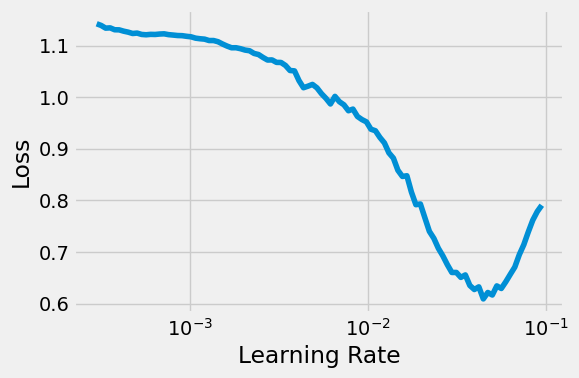

In [52]:
sbs_new = StepByStep(new_model, multi_loss_fn, new_optimizer)
tracking, fig = sbs_new.lr_range_test(train_loader, end_lr=1e-1, num_iter=100)

좋다!
드디어 `"U"` 형태의 곡선이 나타났다.

보아하니,
Karpathy Constant인 `3e-4`는
우리 모델에는 너무 작은 learning rate였던 것 같다.

우리가 주목해야 할 부분은
곡선이 감소(descending)하는 영역이다.

즉,
대략:

```text
0.01 근처
```

의 learning rate를 사용하는 것이 적절해 보인다.

이는 우리가 모델 학습 시:

* `0.005`
  같은 더 큰 learning rate를 사용할 수도 있었다는 의미이다.

하지만 그렇게 하려면,
optimizer를 새로 생성하고,
이를 `sbs_new` 내부에 다시 설정해주어야 한다.

먼저,
optimizer를 설정하는 메서드부터 만들어보자.


In [53]:
def set_optimizer(self, optimizer):
    self.optimizer = optimizer
    
setattr(StepByStep, 'set_optimizer', set_optimizer)

그 다음,
새로운 optimizer를 생성하여 설정하고,
평소와 같은 방식으로 모델을 학습시킨다.


In [54]:
new_optimizer = optim.Adam(new_model.parameters(), lr=0.005)
sbs_new.set_optimizer(new_optimizer)
sbs_new.set_loaders(train_loader, val_loader)
sbs_new.train(10)

직접 시도해보면,
training loss가 실제로 조금 더 빠르게 감소한다는 것을 확인할 수 있다.
(그리고 모델이 과적합(overfitting)될 수도 있다.)

⚠️ 주의:

Learning rate finder는 결코 마법이 아니다!

때로는 `"U"` 형태의 곡선이 나타나지 않을 수도 있다.

그 이유는 예를 들어:

* optimizer에 설정된 초기 learning rate가 이미 너무 높거나,
* `end_lr`이 너무 낮기 때문일 수 있다.

또는 `"U"` 형태의 곡선이 나타난다고 하더라도,
감소 구간(descending part)의 중간 지점이 반드시
해당 모델에 가장 빠른 learning rate를 의미하는 것은 아니다.

💡 “좋습니다. 그러면 처음부터 좋은 learning rate를 선택하면 끝인가요?”

아쉽지만 아니다!

물론 단순한 문제에서는 괜찮을 수도 있다.
단, 여기서 말하는 단순한 문제는 toy problem이 아니라 실제 문제 중 비교적 단순한 경우를 의미한다.

문제는 더 큰 모델에서는 loss surface가 매우 복잡해진다는 점이다.
(Chapter 0에서 보았던 loss surface를 기억해보자.)

모델 학습 초기에 잘 작동하던 learning rate가,
학습 후반부에는 너무 클 수 있다.

즉,
learning rate는 학습 과정에 따라 변화하거나 적응(adapt)해야 한다.


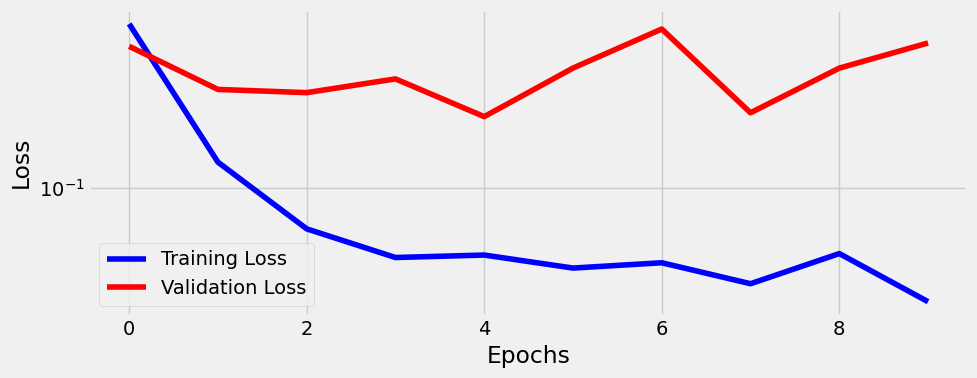

In [55]:
# This plot wasn't included in the book
fig = sbs_new.plot_losses()

### LRFinder

위에서 우리가 구현한 함수는 상당히 기본적인 형태이다.

더 많은 기능이 포함된 구현을 원한다면,
다음 Python 패키지를 참고할 수 있다.

```text
torch_lr_finder
```

여기서는 이 패키지의 사용법을 간단히 보여줄 것이다.

사용 방식은 앞에서 우리가 직접 구현한 방법과 상당히 비슷하다.

다만 더 자세한 내용은 해당 패키지의 문서(documentation)를 참고하기 바란다.


In [57]:
#!pip install --quiet torch-lr-finder
from torch_lr_finder import LRFinder

함수를 직접 호출하는 대신,
먼저 `LRFinder`의 인스턴스를 생성해야 한다.

이때 일반적인 모델 설정 객체들을 전달한다.

즉:

* model
* optimizer
* loss function
* device

를 사용하여 `LRFinder` 객체를 만든다.

그 다음,
`range_test()` 메서드를 실행할 수 있다.

이 메서드에는 우리가 이미 익숙한 인자들을 전달한다.

* data loader
* learning rate의 상한값(`end_lr`)
* iteration 횟수

마지막으로,
`reset()` 메서드는
모델(model)과 optimizer의 원래 상태(original states)를 복원해준다.


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 9.02E-03


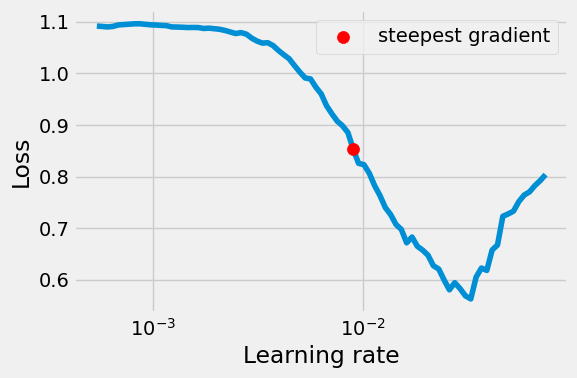

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

torch.manual_seed(11)
new_model = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(new_model.parameters(), lr=3e-4)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr_finder = LRFinder(new_model, new_optimizer, multi_loss_fn, device=device)
lr_finder.range_test(train_loader, end_lr=1e-1, num_iter=100)
lr_finder.plot(ax=ax, log_lr=True)

fig.tight_layout()
lr_finder.reset()

완전한 `"U"` 형태는 아니지만,
그래도 대략 `1e-2`, 즉:

```text
0.01
```

근처가 좋은 시작점(starting point)이라는 점은 알 수 있다.


### Adaptive Learning Rate

사실 Adam optimizer가 바로 그런 일을 해주고 있는 것이다.

Adam은 처음에는 인자로 전달된 learning rate를 사용하지만,
학습이 진행되면서 learning rate를 적응적으로(adaptively) 조정한다.

그리고 이 조정은 모델의 각 parameter마다 서로 다르게 이루어진다.

…정말 그럴까?

정확히 말하자면,
Adam은 learning rate 자체를 조정하는 것이 아니다.

실제로 Adam이 조정하는 것은 gradient이다.

하지만 parameter update는:

* learning rate
* gradient

의 곱으로 결정되기 때문에,
실질적으로는 거의 같은 의미라고 볼 수 있다.

Adam은 두 가지 optimizer의 특징을 결합한 방식이다.

* SGD(with momentum)
* RMSProp

먼저 SGD(with momentum)처럼,
Adam은 gradient 자체 대신
gradient의 moving average를 사용한다.
(통계 용어로는 first moment라고 부른다.)

또한 RMSProp처럼,
gradient의 제곱값(squared gradients)의 moving average를 사용하여
gradient를 scaling한다.
(통계 용어로는 second moment,
또는 uncentered variance라고 한다.)

그런데 여기서 사용하는 것은 단순한 평균(simple average)이 아니다.

moving average이다.

그리고 그냥 moving average도 아니다.

바로 exponentially weighted moving average(EWMA),
즉 지수 가중 이동 평균이다.

하지만 EWMA를 본격적으로 살펴보기 전에,
먼저 simple moving average에 대해 간단히 짚고 넘어가야 한다.


#### Moving Average (MA)

어떤 feature (x)의 moving average(이동 평균)를 일정 기간(periods) 동안 계산하려면,

해당 기간 동안 관측된 값들의 평균을 구하면 된다.

즉,
초기값(현재 시점으로부터 `periods - 1` 단계 이전에 관측된 값)부터
현재 시점의 값까지를 모두 평균내는 것이다.


$$
\large
\text{MA}_t(\text{periods}, x) = \frac{1}{\text{periods}}(x_t + x_{t-1} + \ldots + x_{t-\text{periods}+1})
$$

하지만 값(value) 자체의 평균을 구하는 대신,
각 값의 평균 나이(average age)를 계산해보자.

현재 값(current value)의 나이(age)는
1 단위 시간(unit of time)이고,

moving average 안에서 가장 오래된 값(oldest value)의 나이는
`periods` 단위 시간이다.

따라서 평균 나이(average age)는
아래 공식으로 표현할 수 있다.


$$
\large
\text{average age}_{\text{MA}} = \frac{1+2+\cdots+\text{periods}}{\text{periods}} = \frac{\text{periods}+1}{2}
$$

5-period moving average의 경우,
값들의 평균 나이(average age)는 3 단위 시간(time units)이 된다.

💡 “왜 값들의 평균 나이에 관심을 가지는 건가요?”

단순 moving average 관점에서는
조금 쓸데없어 보일 수도 있다.

하지만 다음 subsection에서 보게 되겠지만,
EWMA는 공식 안에서 period 수를 직접 사용하지 않는다.

대신,
EWMA의 “값들의 평균 나이”를 이용하여
그 moving average가 몇 개의 period와 동등한지(equivalent number of periods)를 추정해야 한다.

💡 “그렇다면 왜 굳이 EWMA를 사용하는 건가요?”


#### EWMA

EWMA(Exponentially Weighted Moving Average)는
전통적인 moving average보다 계산하기 더 실용적(practical)이다.

왜냐하면 EWMA는 단 두 개의 입력값만 필요로 하기 때문이다.

* 이전 단계의 EWMA 값
* 현재 시점의 값(current value)

즉,
과거 전체 데이터를 다시 계산할 필요가 없다.

EWMA 공식은 일반적으로:

* alpha(α)
* 또는 beta(β)

를 사용하여 두 가지 방식으로 표현할 수 있다.


$$
\large
\begin{aligned}
\text{EWMA}_t(\alpha, x)
&=
\alpha x_t
+
(1-\alpha)\,\text{EWMA}_{t-1}(\alpha, x)
\\[0.5em]
\text{EWMA}_t(\beta, x)
&=
(1-\beta)x_t
+
\beta\,\text{EWMA}_{t-1}(\beta, x)
\end{aligned}
$$

첫 번째 방식,
즉 현재 값(current value)의 가중치로 alpha(α)를 사용하는 표현은
금융(finance)과 같은 다른 분야에서 가장 일반적으로 사용된다.

하지만 이상하게도,
Adam optimizer를 설명할 때는
beta(β)를 사용하는 표현이 더 흔하게 사용된다.


이제 첫 번째 방식,
즉 alpha(α)를 사용하는 표현을 기준으로
공식을 조금 더 전개(expand)해보자.


$$
\large
\begin{aligned}
\text{EWMA}_t(\alpha, x)
&=
\alpha x_t
+
(1-\alpha)
\left(
\alpha x_{t-1}
+
(1-\alpha)\,
\text{EWMA}_{t-2}(\alpha, x)
\right)
\\[0.7em]

&=
\alpha x_t
+
(1-\alpha)\alpha x_{t-1}
+
(1-\alpha)^2 \alpha x_{t-2}
+\cdots
\\[0.7em]

&=
(1-\alpha)^0 \alpha x_t
+
(1-\alpha)^1 \alpha x_{t-1}
+
(1-\alpha)^2 \alpha x_{t-2}
+\cdots
\\[0.7em]

&=
\alpha
\Big(
(1-\alpha)^0 x_t
+
(1-\alpha)^1 x_{t-1}
+
(1-\alpha)^2 x_{t-2}
+\cdots
\Big)
\end{aligned}
$$

첫 번째 항(first element)은 그대로 사용된다.

하지만 나머지 항들은 모두
각각의 lag(시차)에 따라 할인(discount)된다.

💡 “lag가 무엇인가요?”

lag는 단순히
현재 시점(current value)으로부터 얼마나 떨어져 있는지를 나타내는 시간 거리(distance)이다.

예를 들어,
1 단위 시간 이전의 feature (x) 값은
lag 1의 값이라고 부른다.

이제 위 식을 계속 전개해보면,
각 항(term)에
해당 lag 수에 따라 지수(exponent)가 붙는 형태의 식을 얻게 된다.

그리고 이 정보를 이용하면,
이를 하나의 합(sum) 형태로 표현할 수 있다.


$$
\large
\text{EWMA}_t(\alpha, x) = \alpha \sum_{\text{lag}=0}^{T-1}\underbrace{(1-\alpha)^{\text{lag}}}_{\text{weight}} x_{t-\text{lag}}
$$

위 식에서 (T)는 관측된 전체 값의 개수(total number of observed values)를 의미한다.

즉,
EWMA는 과거의 모든 값을 고려한다.
아무리 오래된 값이라도 계산에 포함된다.

하지만 가중치(weight),
즉 discount factor가 적용되기 때문에,
값이 오래될수록 합(sum)에 기여하는 정도는 점점 작아진다.

💡

> alpha 값이 클수록,
> 가중치(weights)는 더 빠르게 감소한다.

즉,
오래된 값들은 거의 영향을 주지 않게 된다.

이제 두 가지 경우에서
lag에 따른 가중치(weight)가 어떻게 분포하는지 살펴보자.

* alpha = 1/3인 EWMA
* 단순 5-period moving average

를 비교해보자.


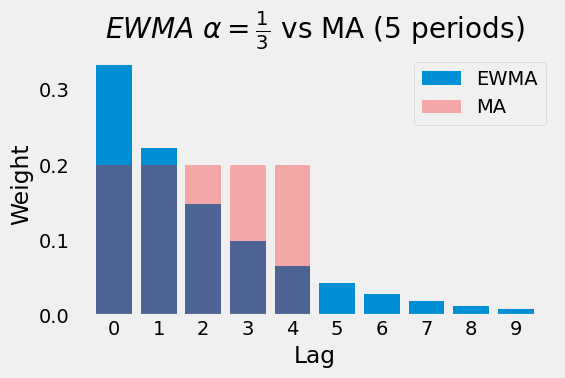

In [59]:
fig = figure15()

차이가 보이는가?

단순 moving average에서는
모든 값(value)이 동일한 가중치(weight)를 가진다.

즉,
모든 값이 평균에 동일하게 기여한다.

하지만 EWMA에서는
최근 값(recent values)이 오래된 값(older values)보다 더 큰 가중치를 가진다.

겉보기에는 달라 보이지만,
사실 위의 두 평균에는 공통점이 하나 있다.

바로,
값들의 평균 나이(average age)가 거의 같다는 것이다.

흥미롭지 않은가?

예를 들어,
5-period moving average의 값들의 평균 나이가 3이라면,

위 EWMA의 값들의 평균 나이 역시
대략 같은 값이 되어야 한다.

왜 그런지 이해해보자.

아마 아직 눈치채지 못했을 수도 있지만,

* lag 0 → 나이(age) 1
* lag 1 → 나이(age) 2

와 같은 관계를 가진다.

즉,
lag 값보다 실제 나이는 항상 1만큼 크다.

이 정보를 이용하면,
EWMA에서 값들의 평균 나이(average age)를 계산할 수 있다.


$$
\large
\text{average age}_{\text{EWMA}} = \alpha \sum_{\text{lag}=0}^{T-1}(1-\alpha)^{\text{lag}} (\text{lag}+1) \approx \frac{1}{\alpha}
$$

관측된 값의 전체 개수 (T)가 커질수록,
평균 나이(average age)는 alpha의 역수에 가까워진다.

즉,

```text
average age ≈ 1 / alpha
```

가 된다.

여기서 이 관계를 수식으로 증명하지는 않겠다.

대신,
이를 수치적으로 “증명”해주는 코드 조각을 보여줄 것이다. :-)

(T) 값을 무한대에 가깝게 만들기 위해
끝없이 큰 값을 넣어볼 수도 있겠지만,

사실 핵심을 보여주기에는
20 periods 정도면 충분하다.


In [60]:
alpha = 1/3; T = 93
t = np.arange(1, T + 1)
age = alpha * sum((1 - alpha)**(t - 1) * t)
age

3.0

대략 3 정도면 충분히 가깝지 않은가?

그래도 확신이 들지 않는다면,
93 periods 또는 그보다 더 큰 값을 사용해보면 된다.

이제 우리는 alpha 값이 주어졌을 때,
EWMA의 평균 나이(average age)를 계산하는 방법을 알게 되었다.

따라서 이 EWMA와 동일한 평균 나이를 가지는
단순 moving average가 무엇인지도 알아낼 수 있다.


$$
\large
\text{average age} = \frac{\text{periods} + 1}{2} = \frac{1}{\alpha} \implies \alpha = \frac{2}{\text{periods}+1};\ \text{periods} = \frac{2}{\alpha}-1
$$

좋다.
이제 alpha 값과 moving average의 period 수 사이에
간단하고 직관적인 관계가 생겼다.

여기서 alpha 값으로 (1/3)을 넣으면 어떻게 될까?

이에 대응하는 period 수는:

```text
5
```

가 된다.

즉,

> alpha = 1/3인 EWMA는
> 5-period moving average에 대응한다.

반대로도 가능하다.

예를 들어,
19-period moving average와 동등한 EWMA를 만들고 싶다면,

대응되는 alpha 값은:

```text
0.1
```

이 된다.

그리고 beta 기반 EWMA 공식을 사용한다면,
beta 값은:

```text
0.9
```

가 된다.

마찬가지로,
1999-period moving average에 대응하는 EWMA를 생각해보면,

* alpha = 0.001
* beta = 0.999

가 된다.

이 값들은 결코 우연히 선택된 것이 아니다.

실제로 Adam optimizer는
바로 이러한 beta 값들을 사용한다.

* 하나는 gradient의 moving average용
* 다른 하나는 squared gradient의 moving average용

beta 값이다.

이제 코드에서,
alpha 버전 EWMA의 구현은 다음과 같은 형태가 된다.


In [61]:
def EWMA(past_value, current_value, alpha):
    return (1 - alpha) * past_value + alpha * current_value

주어진 period에 대해,
값들의 시계열(series of values)에 대해 EWMA를 계산하려면
다음과 같은 함수를 정의할 수 있다.


In [62]:
def calc_ewma(values, period):
    alpha = 2 / (period + 1)
    result = []
    for v in values:
        try:
            prev_value = result[-1]
        except IndexError:
            prev_value = 0

        new_value = EWMA(prev_value, v, alpha)
        result.append(new_value)
    return np.array(result)

`try...except` 블록을 보면,
EWMA의 이전 값(previous value)이 없는 경우,
즉 가장 첫 번째 step에서는 이전 값을 0으로 가정한다는 것을 알 수 있다.

하지만 EWMA가 구성되는 방식에는 문제가 있다.

EWMA는 해당 period 안에 있는 모든 값을 직접 저장하거나 추적할 필요가 없다.
그 대신 이전 EWMA 값과 현재 값만을 사용한다.

그렇기 때문에 초기 단계에서는
계산된 “평균”이 실제 평균에서 크게 벗어날 수 있다.
즉, 편향(bias)이 발생한다.

예를 들어,
`alpha = 0.1`인 경우를 생각해보자.
이는 19-period moving average에 해당한다.

이때 첫 번째 “평균”은
정확히 첫 번째 값을 10으로 나눈 값이 된다.

이 문제를 해결하기 위해,
bias-corrected EWMA,
즉 편향 보정 EWMA를 계산할 수 있다.


$$
\large \text{Bias Corrected EWMA}_t(x, \beta) = \frac{1}{1 - \beta^t}\text{EWMA}_t(x, \beta)
$$

In [63]:
def correction(averaged_value, beta, steps):
    return averaged_value / (1 - (beta ** steps))

위 공식에서의 beta는 이전과 동일하게:

```text
beta = 1 - alpha
```

를 의미한다.

코드에서는 이 bias correction factor(편향 보정 계수)를
다음과 같이 구현할 수 있다.


In [64]:
def calc_corrected_ewma(values, period):
    ewma = calc_ewma(values, period)
    
    alpha = 2 / (period + 1)
    beta = 1 - alpha
    
    result = []
    for step, v in enumerate(ewma):
        adj_value = correction(v, beta, step + 1)
        result.append(adj_value)
        
    return np.array(result)

이제 두 가지 EWMA와
일반적인 moving average를 함께 사용하여,

온도(temperature) 값들의 시퀀스(sequence)에 적용해보자.

이를 통해
각 방법의 차이점을 더 명확하게 확인할 수 있다.


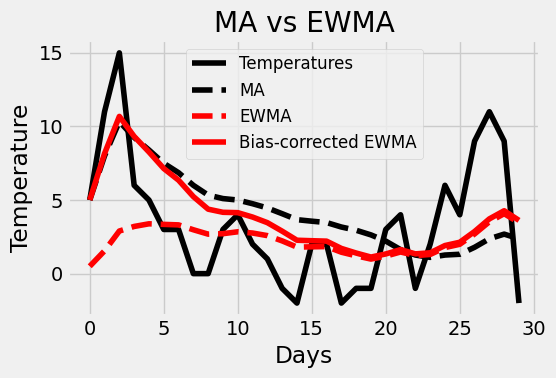

In [65]:
temperatures = np.array([5, 11, 15, 6, 5, 3, 3, 0, 0, 3, 4, 2, 1, 
    -1, -2, 2, 2, -2, -1, -1, 3, 4, -1, 2, 6, 4, 9, 11, 9, -2])

fig = ma_vs_ewma(temperatures, periods=19)

예상했던 것처럼,
보정되지 않은 EWMA(빨간 점선)는
초기 구간에서 실제 값과 상당히 큰 차이를 보인다.

반면,
일반 moving average(검은 점선)는
초기부터 실제 값을 훨씬 더 잘 따라간다.

하지만 보정된(corrected) EWMA는
처음부터 실제 값을 매우 잘 추적(tracking)한다.

그리고 당연하게도,
19일 정도가 지나면
두 EWMA는 거의 구별하기 어려울 정도로 비슷해진다.


#### EWMA Meets Gradients

그런데 온도 값이 뭐가 그렇게 중요하겠는가?

이제 EWMA를 우리의 gradient에 적용해보자.
Adam 방식으로 말이다!

각 parameter에 대해 우리는 두 개의 EWMA를 계산한다.

* 하나는 gradient에 대한 EWMA
* 다른 하나는 gradient 제곱값에 대한 EWMA

그 다음,
이 두 값을 사용하여
해당 parameter에 대한 조정된 gradient(adapted gradient)를 계산한다.


$$
\large \text{adapted-gradient}_t = \frac{\text{Bias Corrected EWMA}_t(\beta_1, \text{gradients})}{\sqrt{\text{Bias Corrected EWMA}_t(\beta_2, \text{gradients}^2)}+\epsilon}
$$

드디어 등장했다!
Adam의 `beta1`과 `beta2` 파라미터이다.

기본값(default values)인:

* `0.9`
* `0.999`

는 각각:

* 19-period average
* 1999-period average

에 대응한다.

즉,

* gradient를 부드럽게(smoothing) 만들기 위한 단기(short-term) 평균
* gradient를 scaling하기 위한 매우 장기(long-term) 평균

을 동시에 사용하는 것이다.

그리고 분모(denominator)에 들어가는 epsilon 값
(보통 `1e-8`)은
단지 수치적 문제(numerical issues)를 방지하기 위해 존재한다.

예를 들어:

* 0으로 나누기(divide by zero)
* 너무 작은 값으로 인한 불안정성

같은 문제를 막기 위한 것이다.

이렇게 adapted gradient(조정된 gradient)가 계산되면,
parameter update 과정에서는
원래 gradient 대신 이 adapted gradient를 사용하게 된다.


$$
\Large
\begin{aligned}
\ \text{SGD}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{gradient}_t
\\
\text{Adam}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{adapted gradient}_t
\end{aligned}
$$

분명히 볼 수 있듯이,
learning rate(그리스 문자 eta, (\eta)) 자체는 전혀 변경되지 않는다!

또한 scaling 과정의 결과로,
adapted gradient는 대부분의 경우:

```text
[-3, 3]
```

범위 안에 들어가게 된다.

이 과정은 일종의 표준화(standardization)와 비슷하다.

다만 차이점은,
일반적인 표준화처럼 평균(mean)을 빼지는 않는다는 점이다.


#### Adam

따라서 Adam optimizer를 선택하는 것은
learning rate 문제를 다루는 가장 쉽고 직관적인 방법 중 하나라고 할 수 있다.

이제 PyTorch의 Adam optimizer와
그 인자(arguments)를 좀 더 자세히 살펴보자.

* `params`
  : 모델의 parameter들

* `lr`
  : learning rate
  (기본값: `1e-3`)

* `betas`
  : EWMA를 위한 `beta1`, `beta2` 값을 담은 tuple

* `eps`
  : 분모에 들어가는 epsilon 값 (`1e-8`)

위 네 개의 인자는 이제 충분히 익숙할 것이다.

하지만 아직 다루지 않은 두 개의 인자가 더 있다.

* `weight_decay`
  : L2 penalty

* `amsgrad`
  : AMSGrad variant 사용 여부

첫 번째 인자인 `weight_decay`는
모델 weight에 regularization term(L2 penalty)을 추가한다.

다른 regularization 기법들과 마찬가지로,
큰 weight 값에 패널티를 부여함으로써
과적합(overfitting)을 방지하는 것이 목적이다.

“weight decay”라는 이름은,
regularization이 실제로는 gradient에
weight 값 × weight_decay 값을 추가하기 때문에 붙은 이름이다.

💡 “gradient를 증가시키는데,
왜 weight decay라고 부르는 건가요?”

parameter update에서는
gradient에 learning rate를 곱한 뒤,
이를 기존 weight 값에서 빼게 된다.

즉,
gradient에 penalty를 추가하면
결과적으로 weight 값이 더 작아진다.

그리고:

* weight가 작아질수록
* penalty도 작아지고
* 이후 감소량도 더 작아진다.

즉,
weight가 점점 감소(decay)하는 형태가 되는 것이다.

두 번째 인자인 `amsgrad`는
optimizer를 AMSGrad라는 변형 버전과 호환되도록 만든다.

간단히 말하면,
adapted gradient를 계산하는 공식을 수정하는 방식이다.

이 방법은:

* bias correction을 제거하고,
* 대신 squared gradient EWMA의 최대값(peak value)을 사용한다.

하지만 지금은
우리가 이미 익숙해진
첫 네 개의 기본 인자들만 사용하도록 하자.


In [66]:
optimizer = optim.Adam(model_cnn2.parameters(), lr=0.0125, betas=(0.9, 0.999), eps=1e-8)

#### Visualizing Adapted Gradients

이제 gradient, EWMA, 그리고 그 결과로 얻어지는 adapted gradient를 직접 시각화할 기회를 제공하고자 한다.

이를 더 쉽게 하기 위해,
이 책 Part I에서 다루었던 단순 선형 회귀 문제를 다시 가져와보자.

그리고 약간의 향수를 느끼며,
gradient를 기록할 수 있도록 training loop를 직접 수행해보자.

참고로,
이제부터 “Learning Rates” 섹션이 끝날 때까지는
오직 단순 선형 회귀 데이터셋만 사용할 것이다.

이 데이터셋을 사용하여,
여러 parameter들이 loss 최소화 과정에 어떤 영향을 미치는지 설명할 것이다.

Rock Paper Scissors 데이터셋으로는
“Putting It All Together” 섹션에서 다시 돌아갈 것이다.

먼저,
데이터 포인트들을 다시 생성하고,
일반적인 데이터 준비 과정을 수행한다.

즉:

* dataset 생성
* training / validation split
* data loader 생성

을 차례로 진행한다.


In [67]:
%run -i data_generation/simple_linear_regression.py
%run -i data_preparation/v2.py

그 다음,
모델 설정(model configuration) 단계로 넘어가서
optimizer를 SGD에서 Adam으로 변경한다.


In [68]:
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
optimizer = optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss(reduction='mean')

사소한 문제가 하나만 없다면,
이제 `StepByStep` 클래스를 사용해 모델을 학습시킬 준비가 된 셈이다.

그 문제는 바로,
아직 gradient를 기록(logging)할 방법이 없다는 것이다.

따라서 이 문제를 해결하기 위해
클래스에 또 하나의 메서드를 추가해보자.

그 메서드의 이름은 `capture_gradients()`이다.

`attach_hooks()` 메서드와 마찬가지로,
이 메서드는 gradient 값을 모니터링할 layer들의 리스트를 입력으로 받는다.

각각의 모니터링 대상 layer에 대해,
이 메서드는 해당 layer의 parameter들을 하나씩 살펴본다.

그리고 gradient가 필요한 parameter,
즉 `requires_grad=True`인 parameter에 대해서는
logging 함수인 `log_fn()`을 생성하고,
그 parameter에 해당하는 tensor에 hook을 등록한다.

이 logging 함수는 단순히
gradient 값을 list에 추가한다.

이 list는 layer 이름과 parameter 이름에 대응하는
dictionary 항목 안에 저장된다.

그 dictionary 자체는 `_gradients`라는 이름의
클래스 attribute이다.

원래는 이 attribute를 constructor method 안에서 생성할 예정이지만,
지금은 임시로 `setattr`을 사용하여 수동으로 설정한다.

코드는 다음과 같은 형태이다.


In [69]:
setattr(StepByStep, '_gradients', {})

def capture_gradients(self, layers_to_hook):
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    modules = list(self.model.named_modules())
    self._gradients = {}
    
    def make_log_fn(name, parm_id):
        def log_fn(grad):
            self._gradients[name][parm_id].append(grad.tolist())
            return
        return log_fn

    for name, layer in self.model.named_modules():
        if name in layers_to_hook:
            self._gradients.update({name: {}})
            for parm_id, p in layer.named_parameters():
                if p.requires_grad:
                    self._gradients[name].update({parm_id: []})
                    log_fn = make_log_fn(name, parm_id)
                    self.handles[f'{name}.{parm_id}.grad'] = p.register_hook(log_fn)
    return

setattr(StepByStep, 'capture_gradients', capture_gradients)

중요: logging 함수는 반드시 `None`을 반환해야 한다.
그렇지 않으면 반환된 값을 기준으로 gradient가 수정되어버린다.

`register_hook()` 메서드는 특정 parameter에 해당하는 tensor에 backward hook을 등록한다.

이 hook 함수는:

* gradient를 입력으로 받고,
* 수정된 gradient 또는 `None`을 반환한다.

이 hook 함수는 해당 tensor에 대한 gradient가 계산될 때마다 호출된다.

우리는 이 함수를 단지 logging 목적으로만 사용하고 있으므로,
gradient는 그대로 두어야 한다.

따라서 반드시 `None`을 반환해야 한다.

💡 “`register_backward_hook()` 메서드도 있지 않나요?
왜 그것을 사용하지 않나요?”

좋은 질문이다.

이 글을 쓰는 시점에는,
`register_backward_hook()` 메서드에 아직 해결되지 않은 문제가 있었다.

그래서 개별 tensor에 대해 `register_hook()`을 사용하는 것이 권장되었다.

이제 새로 만든 메서드를 사용하여
우리 모델의 linear layer에 대한 gradient를 기록할 수 있다.

그리고 학습이 끝난 뒤에는
hook을 제거하는 것을 절대 잊으면 안 된다.


In [70]:
sbs_adam = StepByStep(model, loss_fn, optimizer)
sbs_adam.set_loaders(train_loader, val_loader)
sbs_adam.capture_gradients('linear')
sbs_adam.train(10)
sbs_adam.remove_hooks()

학습이 끝날 때쯤이면,
각각 50개의 gradient로 이루어진 두 개의 시계열(series)을 수집하게 된다.

각 epoch에는 5개의 mini-batch가 있으므로,
총 10 epoch 동안 학습하면:

```text
5 mini-batches × 10 epochs = 50 gradients
```

가 된다.

이 두 개의 시계열은 각각 `linear` layer의 parameter에 대응한다.

* `weight`
* `bias`

그리고 이 값들은 모두 `StepByStep` 인스턴스의 `_gradients` attribute에 저장된다.

이제 이 gradient 값들을 사용하여,
Adam이 실제로 parameter update에 사용하는:

* EWMA
* adapted gradient

를 계산할 수 있다.

먼저 `weight` parameter에 대해 계산해보자.


In [71]:
gradients = np.array(sbs_adam._gradients['linear']['weight']).squeeze()
corrected_gradients = calc_corrected_ewma(gradients, 19)
corrected_sq_gradients = calc_corrected_ewma(np.power(gradients, 2), 1999)
adapted_gradients = corrected_gradients / (np.sqrt(corrected_sq_gradients) + 1e-8)

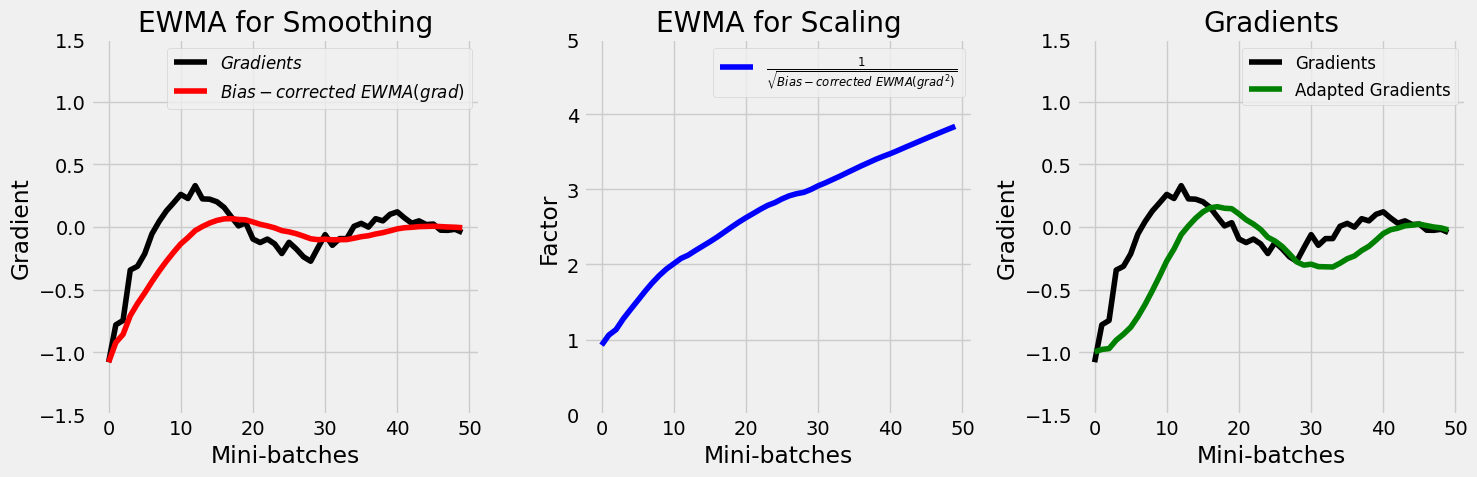

In [72]:
fig = figure17(gradients, corrected_gradients, corrected_sq_gradients, adapted_gradients)

왼쪽 그래프에서는,
gradient의 bias-corrected EWMA가
gradient를 부드럽게 smoothing하고 있음을 볼 수 있다.
이 값은 빨간색으로 표시되어 있다.

가운데 그래프에서는,
squared gradient의 bias-corrected EWMA가
부드럽게 처리된 gradient를 scaling하는 데 사용된다.

오른쪽 그래프에서는,
이 두 EWMA가 결합되어
adapted gradient가 계산된다.

Adam은 내부적으로 각 parameter마다 두 개의 값을 저장한다.

* `exp_avg`
  : gradient에 대한 EWMA
  단, bias correction이 적용되기 전의 값

* `exp_avg_sq`
  : squared gradient에 대한 EWMA
  역시 bias correction이 적용되기 전의 값

이 값들은 optimizer의 `state_dict()`를 확인하면 직접 살펴볼 수 있다.


In [73]:
optimizer.state_dict()

{'state': {0: {'step': tensor(50.),
   'exp_avg': tensor([[-0.0062]]),
   'exp_avg_sq': tensor([[0.0033]])},
  1: {'step': tensor(50.),
   'exp_avg': tensor([0.0405]),
   'exp_avg_sq': tensor([0.0097])}},
 'param_groups': [{'lr': 0.1,
   'betas': (0.9, 0.999),
   'eps': 1e-08,
   'weight_decay': 0,
   'amsgrad': False,
   'maximize': False,
   'foreach': None,
   'capturable': False,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

dictionary의 `state` key 안에는
또 다른 dictionary 두 개가 들어 있다.

이 두 dictionary는 모델의 서로 다른 parameter들을 나타낸다.

다만 key 값이 조금 이상한 숫자 형태로 되어 있다.

우리 예제에서는,
첫 번째 dictionary인:

```text
140614347109072
```

가 `weight` parameter에 해당한다.

우리는 모든 gradient를 기록해두었으므로,
앞에서 만든 `calc_ewma()` 함수를 사용하면
이 dictionary 안에 저장된 값들을 재현(replicate)할 수 있어야 한다.


In [74]:
calc_ewma(gradients, 19)[-1], calc_ewma(np.power(gradients, 2), 1999)[-1]

(-0.006161476466002255, 0.003308466907084168)

보정되지 않은 두 EWMA의 마지막 값을 가져오면,
optimizer 내부 상태인 `exp_avg`와 `exp_avg_sq` 값과 일치한다.

멋지다!

💡 “좋아요, 멋진 건 알겠는데,
실제로 SGD보다 뭐가 더 좋은가요?”

타당한 질문이다.

지금까지는 parameter update 방식이 어떻게 다른지를 논의했다.

이제는 이것이 실제 모델 학습에 어떤 영향을 미치는지 보여줄 차례이다.

Chapter 0에서 이 선형 회귀 문제에 대해 계산했던 loss surface를 다시 가져와보자.

그리고 각 optimizer가 두 parameter를 최적값에 더 가깝게 이동시키기 위해
어떤 경로(path)를 따라가는지 시각화해보자.

그렇게 하면 아주 좋겠지만,
아직 사소한 문제가 하나 더 남아 있다.

우리는 parameter가 학습 과정에서 어떻게 변화하는지를 기록하는 방법도 아직 가지고 있지 않다.

그렇다면 어떻게 해야 할까?

당연히 또 하나의 메서드를 만들 것이다!

새 메서드의 이름은 `capture_parameters()`이다.

이 메서드는 `capture_gradients()`와 비슷한 방식으로 동작한다.

* 클래스 attribute로 `parameters`라는 dictionary를 유지한다.
* parameter 값을 기록하고 싶은 layer에 forward hook을 등록한다.
* logging 함수는 주어진 layer의 parameter들을 반복하면서,
  각 parameter 값을 dictionary의 해당 항목에 추가한다.

hook 등록 자체는 이전에 개발한 메서드인 `attach_hooks()`가 처리한다.

코드는 다음과 같은 형태이다.


In [75]:
setattr(StepByStep, '_parameters', {})

def capture_parameters(self, layers_to_hook):
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    modules = list(self.model.named_modules())
    layer_names = {layer: name for name, layer in modules}
    
    self._parameters = {}
    
    for name, layer in modules:
        if name in layers_to_hook:
            self._parameters.update({name: {}})
            for parm_id, p in layer.named_parameters():
                self._parameters[name].update({parm_id: []})
            
    def fw_hook_fn(layer, inputs, outputs):
        name = layer_names[layer]
        for parm_id, parameter in layer.named_parameters():
            self._parameters[name][parm_id].append(parameter.tolist())
    
    self.attach_hooks(layers_to_hook, fw_hook_fn)
    return
    
setattr(StepByStep, 'capture_parameters', capture_parameters)

다음에는 무엇을 해야 할까?

서로 다른 optimizer를 사용하는 `StepByStep` 인스턴스 두 개를 생성해야 한다.

각 인스턴스는:

* 서로 다른 optimizer를 사용하고,
* parameter 변화를 기록하도록 설정한 뒤,
* 10 epoch 동안 학습시킨다.

이렇게 기록된 parameter들,
즉:

* bias
* weight

는 다음과 같은 경로(path)를 그리게 된다.

그림에서 빨간 점(red dot)은
두 parameter의 최적값(optimal values)을 나타낸다.


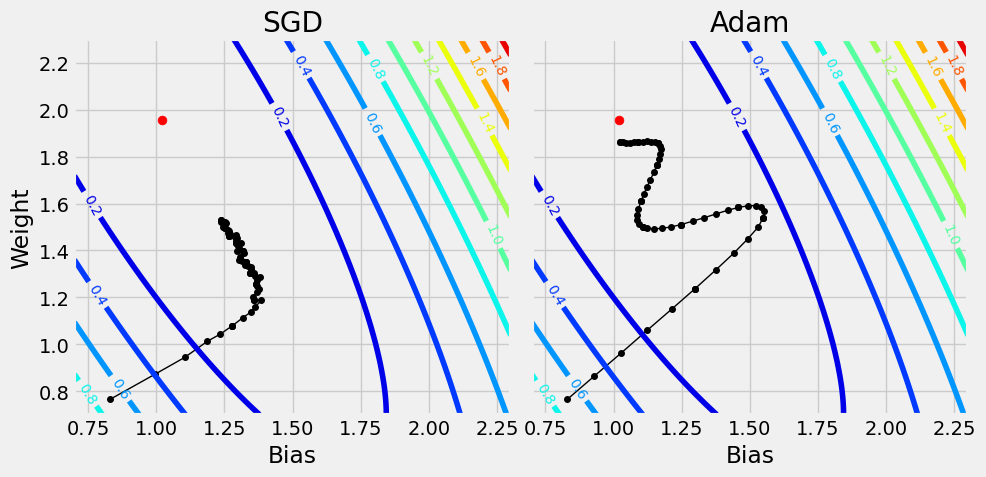

In [76]:
# Generating data for the plots
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
             'Adam': {'class': optim.Adam, 'parms': {'lr': 0.1}}}
results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

b, w, bs, ws, all_losses = contour_data(x_tensor, y_tensor)
fig = plot_paths(results, b, w, bs, ws, all_losses)

왼쪽 그래프는 단순 gradient descent가 따라가는 전형적인 경로를 보여준다.

이 경로는 비교적 안정적(well-behaved)이지만,
속도는 느리다.

또한 mini-batch를 사용하면서 생기는 noise 때문에
경로가 약간 흔들리는(wiggling) 모습도 볼 수 있다.

오른쪽 그래프에서는
exponentially weighted moving average를 사용한 효과를 볼 수 있다.

한편으로는:

* 경로가 더 부드럽고
* 더 빠르게 이동한다.

하지만 다른 한편으로는:

* 목표 지점을 지나쳐 overshoot하기도 하고,
* 목표에 가까워질수록 방향을 앞뒤로 바꾸며 조정한다.

말하자면,
loss surface에 적응(adapt)하고 있는 것이다.

참고로,
optimizer의 경로를 시각화하거나 animation으로 만드는 아이디어가 마음에 든다면,
이 주제에 대한 Louis Tiao의 tutorial[103]을 확인해보는 것도 좋다.

loss 이야기가 나왔으니,
각 optimizer에 대해 training loss와 validation loss의 변화 경로도 비교해볼 수 있다.


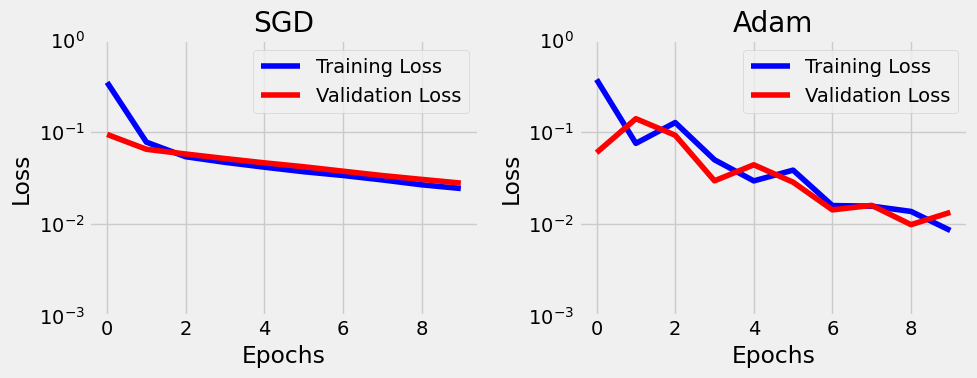

In [77]:
fig = plot_losses(results)

기억하자.

loss는 각 epoch가 끝날 때,
mini-batch들의 loss를 평균내어 계산된다.

왼쪽 그래프에서는,
SGD가 약간 흔들리긴 하지만,
각 epoch마다 이전 epoch보다 더 낮은 loss를 보인다는 것을 확인할 수 있다.

반면 오른쪽 그래프에서는,
overshooting 현상이 training loss 증가 형태로 분명하게 나타난다.

하지만 동시에,
Adam이 더 낮은 loss를 달성했다는 점도 분명하다.

왜냐하면 Adam이
이전 그래프의 빨간 점,
즉 최적값(optimal value)에 더 가까이 도달했기 때문이다.

💡

> 실제 문제(real-world problems)에서는
> loss surface를 직접 그리는 것이 사실상 불가능하다.

따라서 우리는 loss 값을 통해
현재 학습 과정에서 무슨 일이 일어나고 있는지를 요약해서 파악하게 된다.

즉,
loss는 일종의 “executive summary” 역할을 한다.

그리고 training loss는
때때로 잠시 증가했다가 다시 감소할 수도 있다.

이런 현상은 충분히 정상적이며(expected),
이상한 것이 아니다.


## Stochastic Gradient Descent (SGD)

Adaptive learning rate는 정말 멋진 아이디어이다.

하지만 오래된 고전 방식인 stochastic gradient descent(SGD)도
자신만의 몇 가지 비장의 기술(tricks)을 가지고 있다.

이제 PyTorch의 `SGD` optimizer와
그 인자(arguments)를 좀 더 자세히 살펴보자.

* `params`
  : 모델의 parameter들

* `lr`
  : learning rate

* `weight_decay`
  : L2 penalty

위 세 개의 인자는 이미 익숙할 것이다.

하지만 여기에 세 개의 새로운 인자가 더 있다.

* `momentum`
  : momentum factor
  SGD만의 beta 역할을 하는 값이며,
  다음 섹션의 핵심 주제이다.

* `dampening`
  : momentum에 대한 damping factor

* `nesterov`
  : Nesterov momentum 사용 여부
  이는 일반 momentum보다 더 똑똑한(smarter) 방식이며,
  역시 별도의 섹션에서 다룰 것이다.

지금이야말로 momentum을 더 깊이 파고들기에 완벽한 순간이다.
(미안하지만 이런 pun은 도저히 참을 수가 없다!)


### Momentum

SGD의 비장의 기술 중 하나는 바로 momentum이다.

겉으로 보기에는
gradient에 EWMA를 사용하는 것과 매우 비슷해 보인다.

하지만 실제로는 동일하지 않다.

이제 EWMA의 beta 기반 공식과
momentum 공식을 서로 비교해보자.


$$
\Large
\begin{aligned}
\text{EWMA}_t
&=
(1-\beta)\,\text{grad}_t
+
\beta\,\text{EWMA}_{t-1}
\\[0.7em]
\text{momentum}_t
&=
\text{grad}_t
+
\beta\,\text{momentum}_{t-1}
\end{aligned}
$$

차이가 보이는가?

momentum은 gradient의 평균(average)을 계산하지 않는다.

대신,
“discounted” gradient들의 누적합(cumulative sum)을 계산한다.

즉,
과거의 모든 gradient가 합(sum)에 기여하지만,
오래된 gradient일수록 점점 더 큰 discount를 받게 된다.

그리고 이 “discount” 정도는
beta parameter에 의해 결정된다.

momentum 공식을 다음과 같이 다시 쓸 수도 있다.


$$
\Large
\text{momentum}_t = \beta^0\ \text{grad}_t + \beta^1\ \text{grad}_{t-1} + \beta^2\ \text{grad}_{t-2} + \ldots + \beta^n\ \text{grad}_{t-n}
$$

이 두 번째 공식의 단점은,
gradient의 전체 이력(full history)을 모두 필요로 한다는 점이다.

반면,
이전 공식은:

* 현재 gradient 값
* 그리고 가장 최근 momentum 값

만 있으면 계산할 수 있다.

💡 “그렇다면 dampening factor는 무엇인가요?”

dampening factor는 말 그대로
최신 gradient의 영향을 약화(dampen)시키는 방법이다.

즉,
최신 gradient를 momentum에 그대로 모두 더하는 대신,
그 기여도를 감소시킨다.

예를 들어,
dampening factor가 `0.3`이라면,

최신 gradient의:

* 70%

만 momentum에 추가된다.

즉,
gradient의 일부만 반영되는 것이다.

그 공식은 다음과 같이 표현된다.


$$
\Large \text{momentum}_t = (1-\text{damp})\ \text{grad}_t + \beta\ \text{momentum}_{t-1}
$$

💡 dampening factor가 momentum factor(beta)와 같아지면,
그 식은 실제 EWMA와 동일해진다!

Adam과 마찬가지로,
SGD with momentum 역시
각 parameter마다 momentum 값을 따로 저장한다.

그리고 beta parameter 역시
optimizer 내부에 `momentum`이라는 이름으로 저장된다.

이 값들은 optimizer의 `state_dict()`를 통해 직접 확인할 수 있다.


$$
\Large
\begin{aligned}
\text{SGD}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{gradient}_t
\\
\text{Adam}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{adapted gradient}_t
\\
\text{SGD with Momentum}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{momentum}_t
\end{aligned}
$$

In [78]:
# Generating data for the plots
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
             'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

In [79]:
results['SGD + Momentum']['state']

{'state': {0: {'momentum_buffer': tensor([[-0.0308]])},
  1: {'momentum_buffer': tensor([-0.1423])}},
 'param_groups': [{'lr': 0.1,
   'momentum': 0.9,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'params': [0, 1]}]}

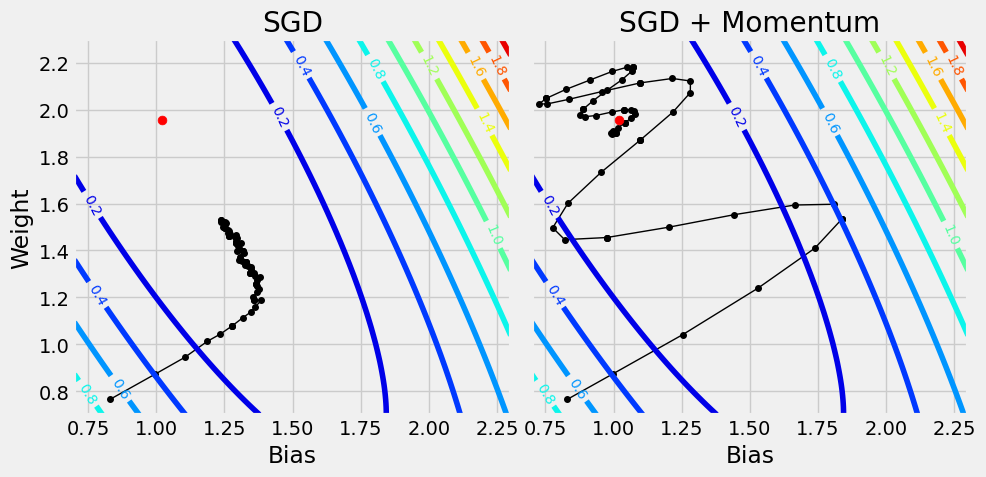

In [80]:
fig = plot_paths(results, b, w, bs, ws, all_losses)

Adam optimizer와 마찬가지로,
SGD with momentum 역시 더 빠르게 이동하며 overshooting 현상을 보인다.

하지만 momentum은 때때로 너무 과하게 움직이는 경향이 있다.

즉,
목표 지점을 지나쳐버리고,
다시 되돌아와 다른 방향에서 접근해야 하는 상황이 발생한다.

Momentum update를 비유하자면,
언덕 아래로 굴러가는 공(ball)과 같다.

공은 점점 속도를 얻어,
계곡 바닥을 지나 반대편 언덕까지 올라간다.

그 후 다시 굴러 내려오는데,
조금 더 작은 속도로 움직인다.

이 과정을 앞뒤로 반복하면서,
결국에는 계곡의 가장 아래(bottom)에 도달하게 된다.

💡 “그렇다면 Adam이 이미 더 좋은 것 아닌가요?”

맞기도 하고,
아니기도 하다.

Adam은 실제로 minimum에 훨씬 빠르게 수렴(converge)한다.

하지만 반드시 “좋은” minimum으로 가는 것은 아니다.

단순 선형 회귀에서는:

* 하나의 global minimum
* 즉 최적 parameter 값

이 존재한다.

하지만 딥러닝 모델은 다르다.

딥러닝에서는:

* minimum이 매우 많고,
* 어떤 minimum은 다른 minimum보다 더 좋다.
  (즉, loss가 더 낮다.)

따라서 Adam은
이 많은 minimum 중 하나를 빠르게 찾아 이동하지만,
근처에 있는 더 좋은 minimum을 놓칠 수도 있다.

반면 momentum은
처음에는 다소 거칠고(sloppy) 비효율적으로 보일 수 있다.

하지만 learning rate scheduler와 함께 사용하면
(곧 자세히 다룰 것이다)

loss surface를 더 넓게 탐색(explore)하면서,
Adam보다 더 좋은 quality의 minimum을 찾을 가능성이 있다.

💡

> Adam과 SGD with momentum
> (특히 learning rate scheduler와 함께 사용하는 경우)
> 둘 다 매우 널리 사용된다.

하지만 언덕 아래를 정신없이 굴러가는 공(ball)의 비유가
너무 통제되지 않은 느낌이라면,
아마 그 변형 버전(variant)을 더 좋아하게 될지도 모른다…


#### Nesterov

#### 여기서부터 COMMENT 추가해야함

$$
\Large
\begin{aligned}
\text{step } t:\qquad
\mathrm{mo}_t
&=
\mathrm{grad}_t
+
\beta\,\mathrm{mo}_{t-1}
\\[0.8em]

\text{step } t+1:\qquad
\mathrm{mo}_{t+1}
&=
\mathrm{grad}_{t+1}
+
\beta\,\mathrm{mo}_t
\end{aligned}
$$

$$
\Large
\begin{aligned}

\text{step } t:\qquad
\mathrm{mo}_t
&=
\mathrm{grad}_t
+
\beta\,\mathrm{mo}_{t-1}
\\[0.8em]

\text{step } t:\qquad
\mathrm{nesterov}_t
&=
\mathrm{grad}_t
+
\beta\,\mathrm{mo}_t
\\[0.8em]

\text{step } t+1:\qquad
\mathrm{mo}_{t+1}
&=
\mathrm{grad}_{t+1}
+
\beta\,\mathrm{mo}_t

\end{aligned}
$$

$$
\Large
\begin{aligned}
\text{SGD with Momentum}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{mo}_t
\\
\text{SGD with Nesterov}: &\text{param}_t = \text{param}_{t-1} - \eta\ \text{nesterov}_t
\end{aligned}
$$

$$
\Large
\begin{aligned}
\text{param}_t & = \text{param}_{t-1} - \eta\ \text{nesterov}_t
\\
& = \text{param}_{t-1} - \eta\ (\text{grad}_t + \beta\ \text{mo}_t)
\\
& = \text{param}_{t-1} - \eta\ \text{grad}_t - \beta\ \eta\ \text{mo}_t
\end{aligned}
$$

#### Flavors of SGD

$$
\Large
\begin{aligned}
\ \text{SGD}: &\text{param}_t = \text{param}_{t-1} &-& \eta\ \text{grad}_t
\\
\text{SGD with Momentum}: &\text{param}_t = \text{param}_{t-1} &&&-&& \eta\ \text{mo}_t
\\
\text{SGD with Nesterov}: &\text{param}_t = \text{param}_{t-1} &-& \eta\ \text{grad}_t &-&\beta &\eta\ \text{mo}_t
\end{aligned}
$$

In [81]:
# Generating data for the plots
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
              'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Nesterov': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

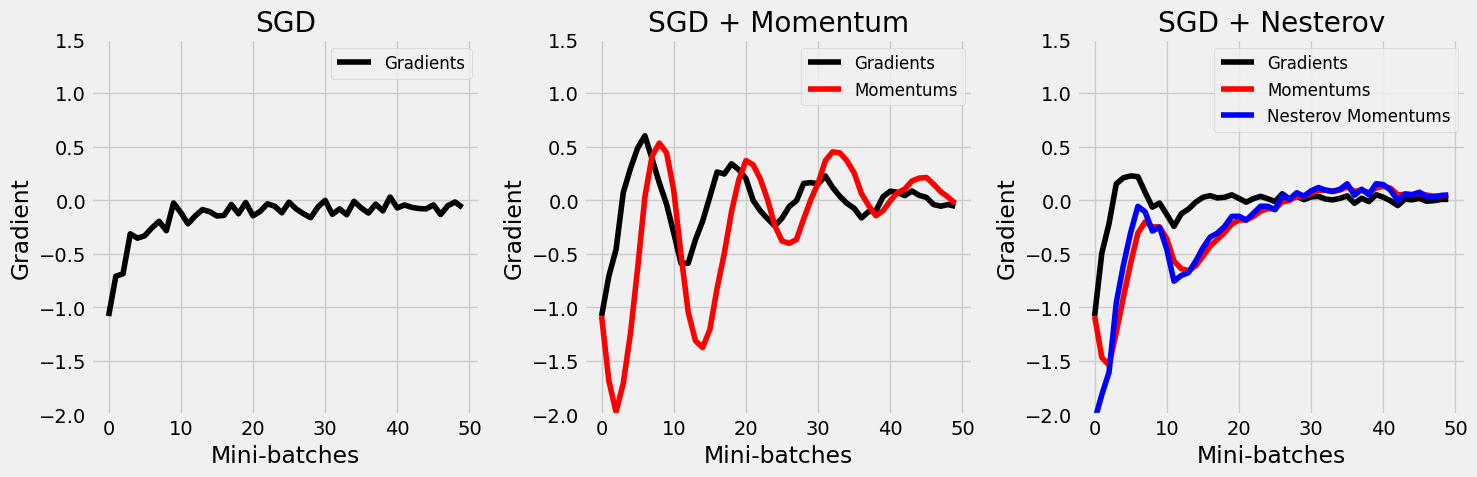

In [82]:
fig = figure21(results)

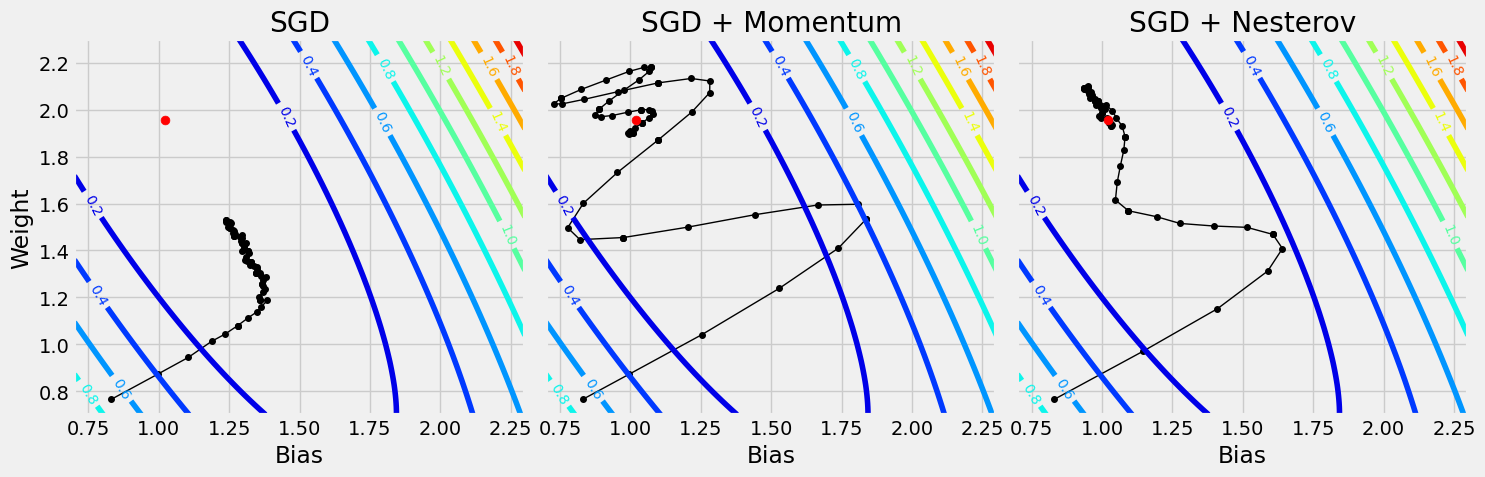

In [83]:
fig = plot_paths(results, b, w, bs, ws, all_losses)

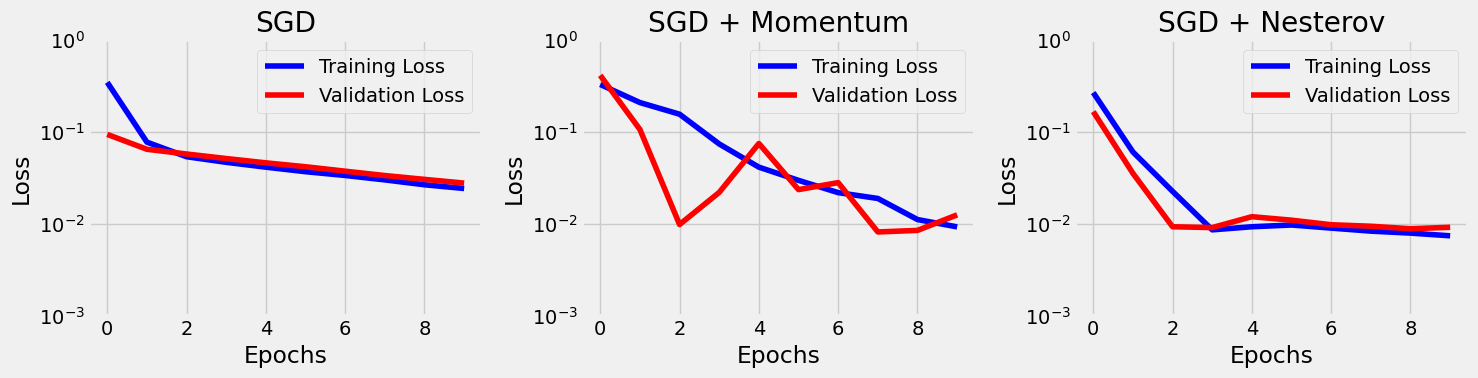

In [84]:
fig = plot_losses(results)

### Learning Rate Schedulers

In [85]:
dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = StepLR(dummy_optimizer, step_size=2, gamma=0.1)

In [86]:
for epoch in range(4):
    # trainin loop code goes here
    
    print(dummy_scheduler.get_last_lr())
    # First call optimizer's step
    dummy_optimizer.step()
    # Then call scheduler's step
    dummy_scheduler.step()
    
    dummy_optimizer.zero_grad()

[0.01]
[0.01]
[0.001]
[0.001]


### Epoch Schedulers

In [87]:
dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = LambdaLR(dummy_optimizer, lr_lambda=lambda epoch: 0.1 ** (epoch//2))
# The scheduler above is equivalent to this one
# dummy_scheduler = StepLR(dummy_optimizer, step_size=2, gamma=0.1)

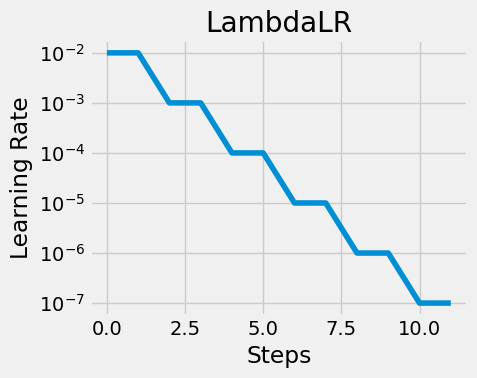

In [88]:
fig = plot_scheduler(dummy_optimizer, dummy_scheduler)

### Validation Loss Scheduler

In [89]:
dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = ReduceLROnPlateau(dummy_optimizer, patience=4, factor=0.1)

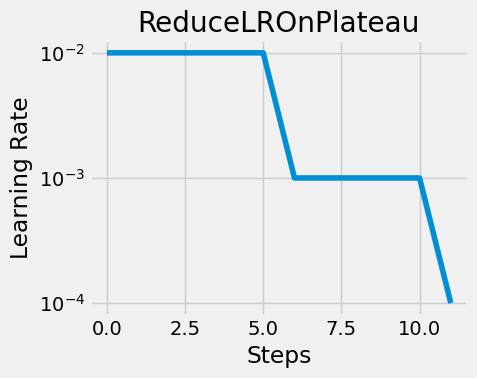

In [90]:
fig = plot_scheduler(dummy_optimizer, dummy_scheduler)

### Scheduler in StepByStep - Part I

In [91]:
setattr(StepByStep, 'scheduler', None)
setattr(StepByStep, 'is_batch_lr_scheduler', False)

def set_lr_scheduler(self, scheduler):
    # Makes sure the scheduler in the argument is assigned to the
    # optimizer we're using in this class
    if scheduler.optimizer == self.optimizer:
        self.scheduler = scheduler
        if (isinstance(scheduler, optim.lr_scheduler.CyclicLR) or
            isinstance(scheduler, optim.lr_scheduler.OneCycleLR) or
            isinstance(scheduler, optim.lr_scheduler.CosineAnnealingWarmRestarts)):
            self.is_batch_lr_scheduler = True
        else:
            self.is_batch_lr_scheduler = False

setattr(StepByStep, 'set_lr_scheduler', set_lr_scheduler)

In [92]:
setattr(StepByStep, 'learning_rates', [])

def _epoch_schedulers(self, val_loss):
    if self.scheduler:
        if not self.is_batch_lr_scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()

            current_lr = list(map(lambda d: d['lr'], self.scheduler.optimizer.state_dict()['param_groups']))
            self.learning_rates.append(current_lr)

setattr(StepByStep, '_epoch_schedulers', _epoch_schedulers)

In [93]:
def train(self, n_epochs, seed=42):
    # To ensure reproducibility of the training process
    self.set_seed(seed)

    for epoch in range(n_epochs):
        # Keeps track of the numbers of epochs
        # by updating the corresponding attribute
        self.total_epochs += 1

        # inner loop
        # Performs training using mini-batches
        loss = self._mini_batch(validation=False)
        self.losses.append(loss)

        # VALIDATION
        # no gradients in validation!
        with torch.no_grad():
            # Performs evaluation using mini-batches
            val_loss = self._mini_batch(validation=True)
            self.val_losses.append(val_loss)

        self._epoch_schedulers(val_loss)

        # If a SummaryWriter has been set...
        if self.writer:
            scalars = {'training': loss}
            if val_loss is not None:
                scalars.update({'validation': val_loss})
            # Records both losses for each epoch under the main tag "loss"
            self.writer.add_scalars(main_tag='loss',
                                    tag_scalar_dict=scalars,
                                    global_step=epoch)

    if self.writer:
        # Closes the writer
        self.writer.close()

setattr(StepByStep, 'train', train)

### Mini-Batch Schedulers

In [94]:
dummy_parm = [nn.Parameter(torch.randn(1))]
dummy_optimizer = optim.SGD(dummy_parm, lr=0.01)

dummy_scheduler1 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='triangular')
dummy_scheduler2 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='triangular2')
dummy_scheduler3 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='exp_range', gamma=np.sqrt(.5))

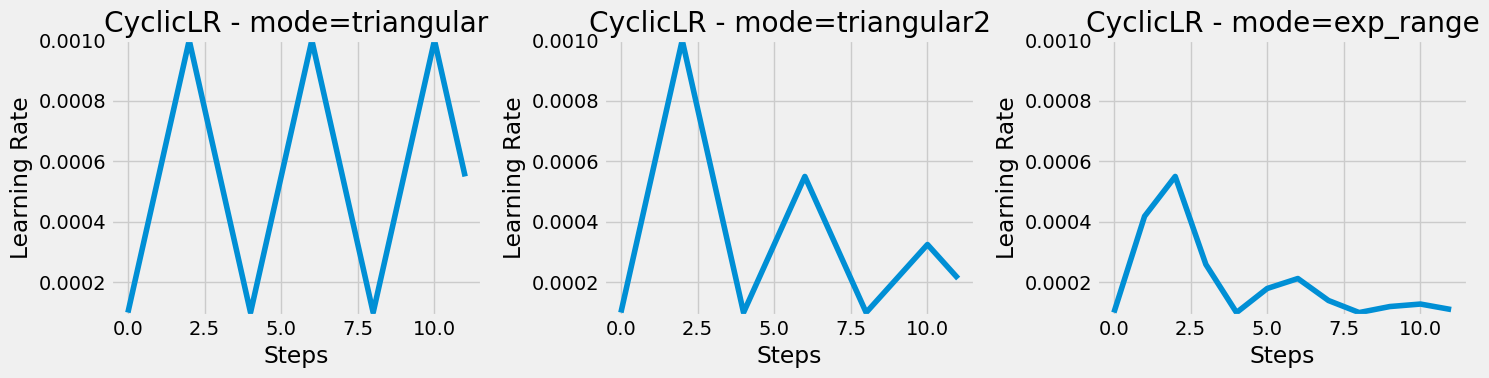

In [95]:
fig = figure26(dummy_optimizer, (dummy_scheduler1, dummy_scheduler2, dummy_scheduler3))

### Schedulers in StepByStep - Part II

In [96]:
def _mini_batch_schedulers(self, frac_epoch):
    if self.scheduler:
        if self.is_batch_lr_scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
                self.scheduler.step(self.total_epochs + frac_epoch)
            else:
                self.scheduler.step()

            current_lr = list(map(lambda d: d['lr'], self.scheduler.optimizer.state_dict()['param_groups']))
            self.learning_rates.append(current_lr)

setattr(StepByStep, '_mini_batch_schedulers', _mini_batch_schedulers)

In [97]:
def _mini_batch(self, validation=False):
    # The mini-batch can be used with both loaders
    # The argument `validation`defines which loader and 
    # corresponding step function is going to be used
    if validation:
        data_loader = self.val_loader
        step_fn = self.val_step_fn
    else:
        data_loader = self.train_loader
        step_fn = self.train_step_fn

    if data_loader is None:
        return None

    n_batches = len(data_loader)
    # Once the data loader and step function, this is the same
    # mini-batch loop we had before
    mini_batch_losses = []
    for i, (x_batch, y_batch) in enumerate(data_loader):
        x_batch = x_batch.to(self.device)
        y_batch = y_batch.to(self.device)

        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

        if not validation:
            self._mini_batch_schedulers(i / n_batches)

    loss = np.mean(mini_batch_losses)
    return loss

setattr(StepByStep, '_mini_batch', _mini_batch)

### Scheduler Paths

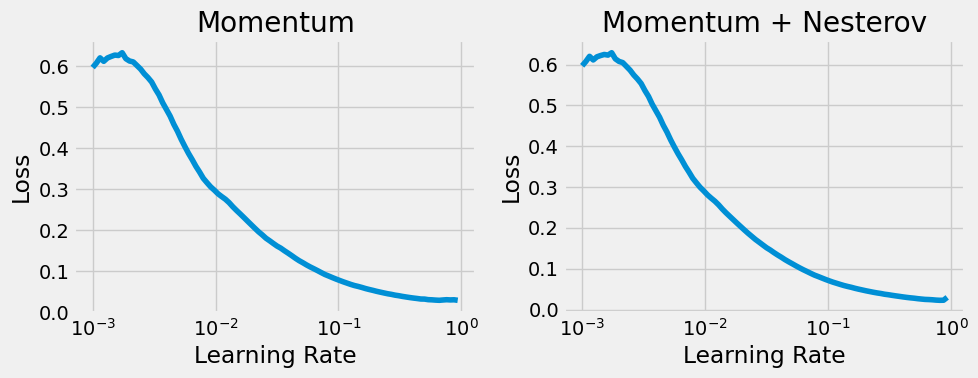

In [98]:
from stepbystep.v3 import StepByStep

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, nesterov in zip(axs.flat, [False, True]):
    torch.manual_seed(42)
    model = nn.Sequential()
    model.add_module('linear', nn.Linear(1, 1))
    loss_fn = nn.MSELoss(reduction='mean')
    optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, nesterov=nesterov)

    sbs_scheduler = StepByStep(model, loss_fn, optimizer)
    tracking, fig = sbs_scheduler.lr_range_test(train_loader, end_lr=1, num_iter=100, ax=ax)
        
    nest = ' + Nesterov' if nesterov else ''
    ax.set_title(f'Momentum{nest}')

In [99]:
step_scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
cyclic_scheduler = CyclicLR(optimizer, base_lr=0.025, max_lr=0.1, step_size_up=10, mode='triangular2')

In [100]:
# Generating data for the plots
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Momentum + Step': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Momentum + Cycle': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Nesterov': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}},
              'SGD + Nesterov + Step': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}},
              'SGD + Nesterov + Cycle': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}}}

schedulers = {'SGD + Momentum + Step': {'class': StepLR, 'parms': {'step_size': 4, 'gamma': 0.5}},
              'SGD + Momentum + Cycle': {'class': CyclicLR, 'parms': {'base_lr': 0.025, 'max_lr': 0.1, 'step_size_up': 10, 'mode': 'triangular2'}},
              'SGD + Nesterov + Step': {'class': StepLR, 'parms': {'step_size': 4, 'gamma': 0.5}},
              'SGD + Nesterov + Cycle': {'class': CyclicLR, 'parms': {'base_lr': 0.025, 'max_lr': 0.1, 'step_size_up': 10, 'mode': 'triangular2'}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, schedulers, n_epochs=10)

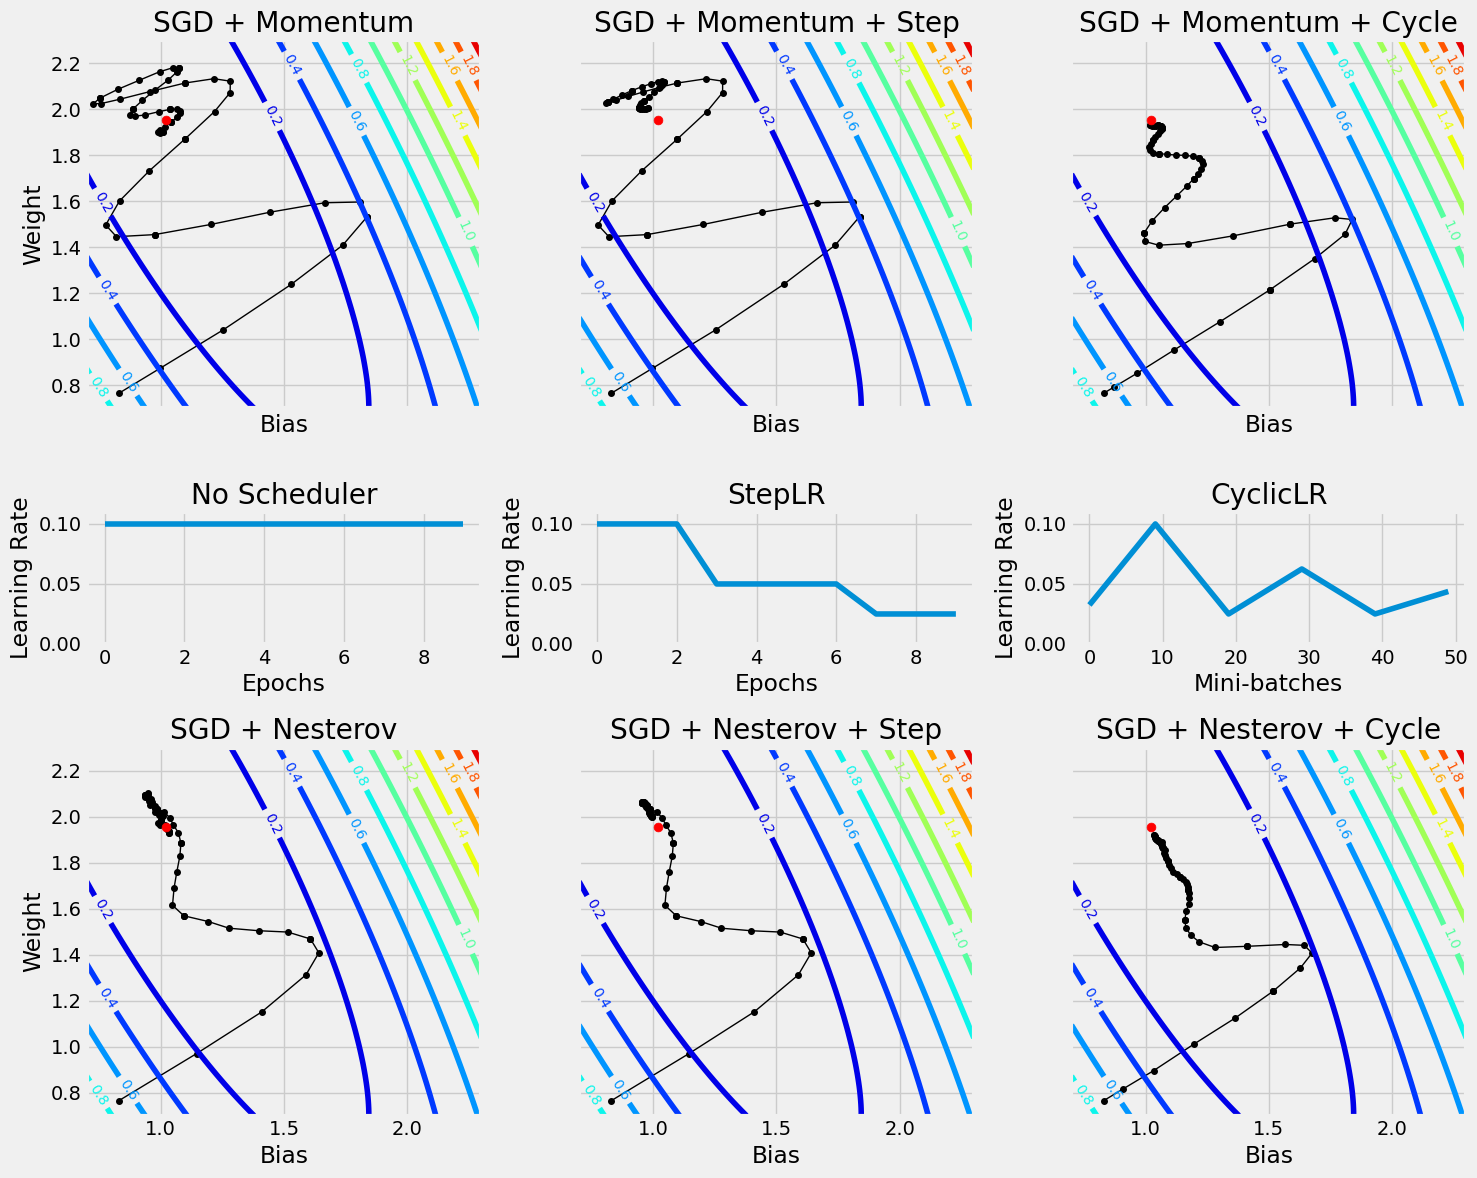

In [101]:
fig = figure28(results, b, w, bs, ws, all_losses)

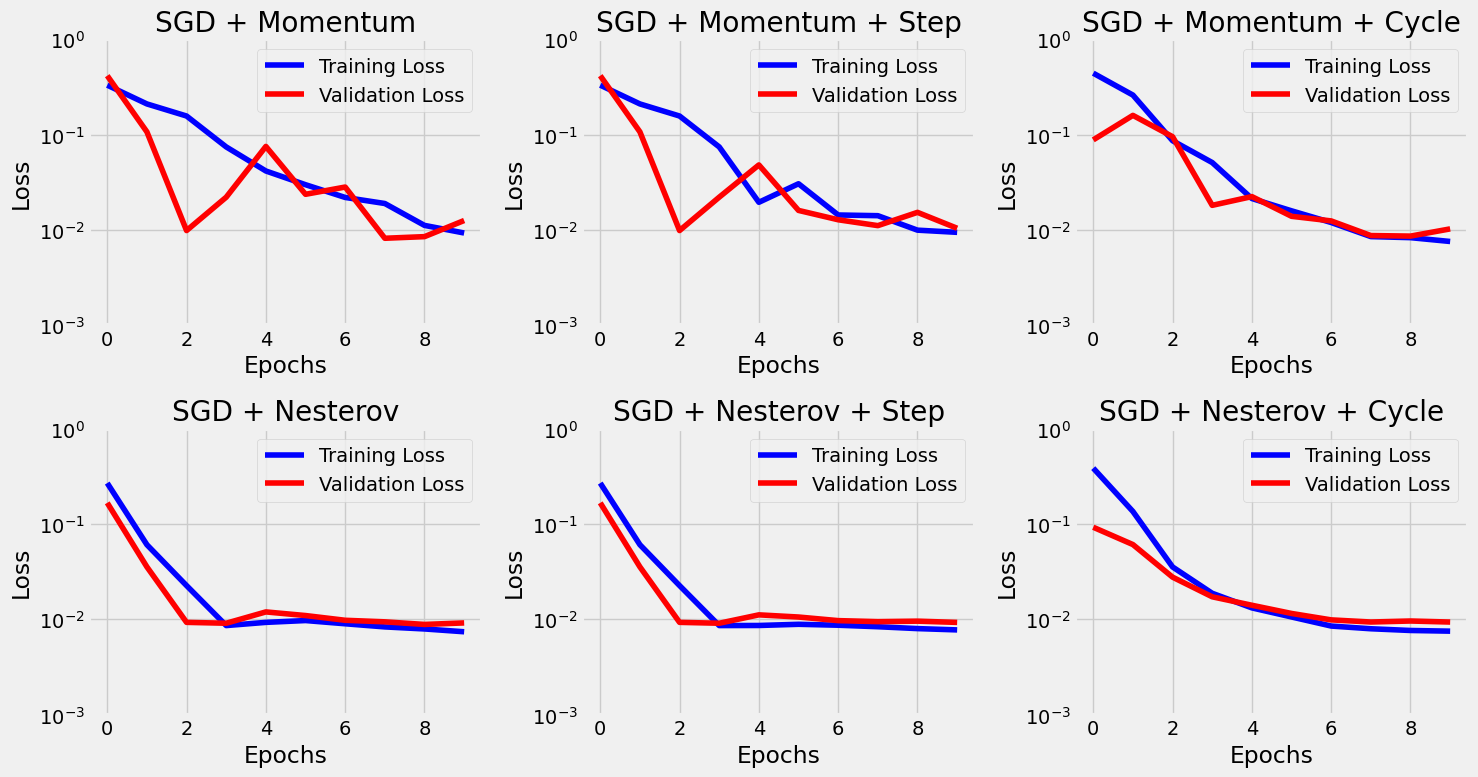

In [102]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flat
fig = plot_losses(results, axs)

# Putting It All Together

In [103]:
# Loads temporary dataset to build normalizer
temp_transform = Compose([Resize(28), ToImage(), ToDtype(torch.float32, scale=True)])
temp_dataset = ImageFolder(root='rps', transform=temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=16)
normalizer = StepByStep.make_normalizer(temp_loader)

# Builds transformation, datasets and data loaders
composer = Compose([Resize(28),
                    ToImage(), 
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='rps', transform=composer)
val_data = ImageFolder(root='rps-test-set', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

In [104]:
torch.manual_seed(13)
model_cnn3 = CNN2(n_feature=5, p=0.5)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=1e-3, momentum=0.9, nesterov=True)

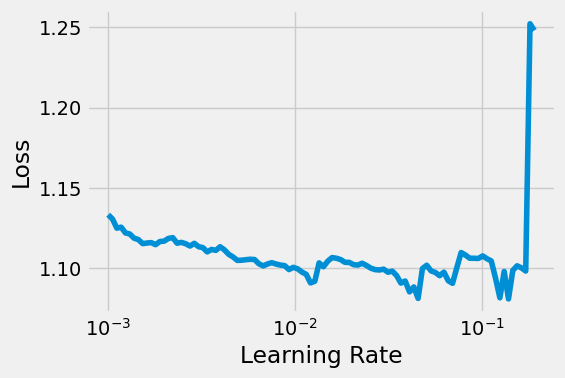

In [105]:
sbs_cnn3 = StepByStep(model_cnn3, multi_loss_fn, optimizer_cnn3)
tracking, fig = sbs_cnn3.lr_range_test(train_loader, end_lr=2e-1, num_iter=100)

In [106]:
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=0.01, momentum=0.9, nesterov=True)
sbs_cnn3.set_optimizer(optimizer_cnn3)

scheduler = CyclicLR(optimizer_cnn3, base_lr=1e-3, max_lr=0.01, step_size_up=len(train_loader), mode='triangular2')
sbs_cnn3.set_lr_scheduler(scheduler)

In [107]:
sbs_cnn3.set_loaders(train_loader, val_loader)
sbs_cnn3.train(10)

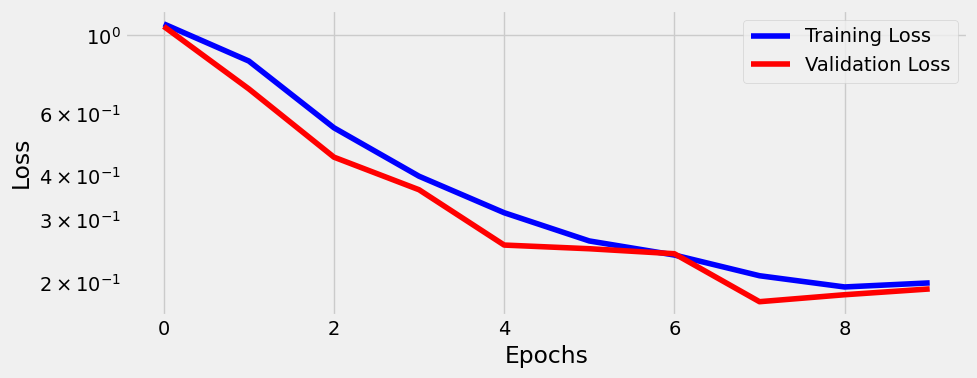

In [108]:
fig = sbs_cnn3.plot_losses()

In [109]:
print(StepByStep.loader_apply(train_loader, sbs_cnn3.correct).sum(axis=0), 
      StepByStep.loader_apply(val_loader, sbs_cnn3.correct).sum(axis=0))

tensor([2506, 2520]) tensor([341, 372])
